# The Qang (qg) — Full Reference Notebook

Companion notebook for:

> V. H. Monteverde, *"The Qang (qg): A Unified Angular-Probability Unit and
> Metric for Parametric Quantum Circuit Design."* ORCID:
> [0000-0001-8884-4811](https://orcid.org/0000-0001-8884-4811) · DOI:
> [10.5281/zenodo.22832150](https://doi.org/10.5281/zenodo.22832150)

Code: [github.com/Viny2030/qang](https://github.com/Viny2030/qang)

This notebook is self-contained (no `pip install qang` needed — every
definition is inlined below, cell by cell) so it opens and runs directly in
Google Colab. It consolidates the exploratory work from the two earlier
Colabs (`quang 1.ipynb`, `quang_explorer_1.ipynb`) into one clean version,
and then extends it along all four "Future Research Directions"
the paper's Section 6 leaves open:

1. **Section 2** — the `Qang` class: `qg_Z` / `qg_S` exactly as defined in
   the paper, the full (theta, phi) Bloch-sphere representation, the
   milliqang subunit, and Tables 1 & 2 reproduced from running code.
2. **Section 3** — the Section 4.1 gradient singularity, two regularized
   alternatives, and an empirical benchmark comparing optimizer convergence
   in theta-space vs raw qg-space vs regularized qg-space.
3. **Section 4** — generalization to **mixed states and POVMs** (Future
   Research Direction #4, part 1).
4. **Section 5** — generalization to **multi-qubit** tensor-product
   projection profiles, including the Bell-state entanglement witness
   (Future Research Direction #4, part 2).
5. **Section 5** — `qg` as a **native Qiskit gate** (Future Research
   Direction #1).
6. **Section 6** — **shot-noise error propagation** between
   probability-space and theta/qg-space: how measurement uncertainty in
   `P(|0>)` propagates into `theta_hat`, closed-form and empirically
   validated (Future Research Direction #2).
7. **Section 7** — `qg` as a **native Cirq gate**, completing Future
   Research Direction #1 for a second SDK.

All four "Future Research Directions" from the paper's Section 6 now have a
concrete implementation here. A full pytest suite (116 tests) covering
everything below also ships separately in the `qang` Python package, for
regression-testing the library as code rather than re-running a notebook by
hand.


In [1]:
!pip install -q qiskit qiskit-aer cirq scipy


In [2]:
import math
import cmath
import string
from dataclasses import dataclass, field
from typing import Callable, Dict, List, Sequence, Tuple, Union

import numpy as np
import matplotlib.pyplot as plt


## 1. The `Qang` class (Sections 2.1 – 2.3 of the paper)

- **Polar Bias Qang**: $qg_Z(\theta) = \cos(\theta) = \langle \sigma_z \rangle$, range $[-1, +1]$.
- **Measurement-Outcome Entropy Qang**: $qg_S(\theta) = H(\cos^2(\theta/2))$, the binary
  Shannon entropy of the Z-basis measurement outcome distribution (*not* the von Neumann
  entropy of the state — that is identically zero for any pure state, see Section 4 below).
  Range $[0, 1]$.

Both live on the same `Qang` class, selected by `mode="polar"` / `mode="entropic"`. The
polar mode also carries the full Bloch-sphere `(theta, phi)` representation (consolidated
from the exploratory notebook), so it supports `to_bloch_vector()`, `to_statevector()`, etc.


In [3]:
from __future__ import annotations

from typing import Tuple, Union
import cmath
import math

MILLIQANG_PER_QANG = 1000.0


def _binary_entropy(p: float) -> float:
    """H(p) = -p*log2(p) - (1-p)*log2(1-p), with the 0*log(0) := 0 convention."""
    if p <= 0.0 or p >= 1.0:
        return 0.0
    q = 1.0 - p
    return -(p * math.log2(p) + q * math.log2(q))


class Qang:
    """
    A single value in the qang (qg) unit.

    Parameters
    ----------
    value : float
        qg_Z in [-1.0, 1.0] (mode="polar") or qg_S in [0.0, 1.0] (mode="entropic").
    phi : float, optional
        Azimuthal Bloch angle in radians, only meaningful in ``mode="polar"``
        (qg_S is independent of phi -- the Z-basis outcome distribution
        cos^2(theta/2), sin^2(theta/2) does not depend on the relative phase).
    mode : {"polar", "entropic"}
    """

    __slots__ = ("_value", "_phi", "mode")

    def __init__(self, value: float, phi: float = 0.0, mode: str = "polar"):
        self.mode = mode.lower()
        if self.mode == "polar":
            if not (-1.0 <= value <= 1.0):
                raise ValueError(f"qg_Z (polar) must lie in [-1.0, 1.0], got {value}.")
        elif self.mode == "entropic":
            if not (0.0 <= value <= 1.0):
                raise ValueError(f"qg_S (entropic) must lie in [0.0, 1.0], got {value}.")
        else:
            raise ValueError("mode must be 'polar' or 'entropic'.")
        self._value = float(value)
        self._phi = float(phi) % (2.0 * math.pi)

    # ------------------------------------------------------------------ #
    # basic accessors
    # ------------------------------------------------------------------ #
    @property
    def value(self) -> float:
        return self._value

    @property
    def phi(self) -> float:
        return self._phi

    @property
    def milliqang(self) -> float:
        """value expressed in milliqang (m-qg), Section 2.3 of the paper."""
        return self._value * MILLIQANG_PER_QANG

    @classmethod
    def from_milliqang(cls, m_value: float, phi: float = 0.0, mode: str = "polar") -> "Qang":
        return cls(m_value / MILLIQANG_PER_QANG, phi=phi, mode=mode)

    # ------------------------------------------------------------------ #
    # constructors
    # ------------------------------------------------------------------ #
    @classmethod
    def from_angles(cls, theta: float, phi: float = 0.0, unit: str = "rad",
                     mode: str = "polar") -> "Qang":
        """Build a Qang from the Bloch polar angle theta (and, in polar mode, phi)."""
        is_deg = unit.lower() in ("deg", "degrees", "grados")
        theta_rad = math.radians(theta) if is_deg else float(theta)
        phi_rad = math.radians(phi) if is_deg else float(phi)

        if not (0.0 <= theta_rad <= math.pi + 1e-9):
            raise ValueError(f"theta must lie in [0, pi] rad, got {theta_rad}.")

        if mode == "polar":
            return cls(math.cos(theta_rad), phi=phi_rad, mode="polar")
        elif mode == "entropic":
            p0 = math.cos(theta_rad / 2.0) ** 2
            return cls(_binary_entropy(p0), phi=0.0, mode="entropic")
        raise ValueError("mode must be 'polar' or 'entropic'.")

    @classmethod
    def from_probability(cls, p0: float, p1: Union[float, None] = None,
                          mode: str = "polar") -> "Qang":
        """Build a Qang from the computational-basis outcome probabilities."""
        if not (0.0 <= p0 <= 1.0):
            raise ValueError(f"p0 must lie in [0, 1], got {p0}.")
        if p1 is None:
            p1 = 1.0 - p0
        elif not (0.0 <= p1 <= 1.0):
            raise ValueError(f"p1 must lie in [0, 1], got {p1}.")
        elif abs((p0 + p1) - 1.0) > 1e-4:
            raise ValueError(f"p0 + p1 must equal 1, got {p0 + p1}.")

        if mode == "polar":
            return cls(p0 - p1, mode="polar")
        elif mode == "entropic":
            return cls(_binary_entropy(p0), mode="entropic")
        raise ValueError("mode must be 'polar' or 'entropic'.")

    @classmethod
    def from_bloch_vector(cls, x: float, y: float, z: float, atol: float = 1e-3) -> "Qang":
        """Build a (polar-mode) Qang from a unit Bloch vector (x, y, z)."""
        norm = math.sqrt(x * x + y * y + z * z)
        if abs(norm - 1.0) > atol:
            raise ValueError(f"(x, y, z) must be unit-norm, got norm={norm:.6f}.")
        z_clamped = max(-1.0, min(1.0, z))
        phi = math.atan2(y, x) % (2.0 * math.pi)
        return cls(z_clamped, phi=phi, mode="polar")

    @classmethod
    def from_statevector(cls, alpha: complex, beta: complex, atol: float = 1e-3) -> "Qang":
        """
        Build a (polar-mode) Qang from amplitudes |psi> = alpha|0> + beta|1>,
        after removing the global phase (alpha is rotated to be real and >= 0).
        """
        norm = abs(alpha) ** 2 + abs(beta) ** 2
        if abs(norm - 1.0) > atol:
            raise ValueError(f"|alpha|^2 + |beta|^2 must equal 1, got {norm:.6f}.")

        ref = alpha if abs(alpha) > 1e-12 else beta
        global_phase = cmath.phase(ref)
        a = alpha * cmath.exp(-1j * global_phase)
        b = beta * cmath.exp(-1j * global_phase)

        p0 = abs(a) ** 2
        p1 = abs(b) ** 2
        phi = cmath.phase(b) % (2.0 * math.pi)
        return cls(p0 - p1, phi=phi, mode="polar")

    # ------------------------------------------------------------------ #
    # conversions back out (polar mode only, per Section 2.2's caveat)
    # ------------------------------------------------------------------ #
    def _require_polar(self, what: str):
        if self.mode != "polar":
            raise NotImplementedError(
                f"{what} requires mode='polar': qg_S is not bijective with theta "
                "over [0, pi] (Section 2.2 of the paper) and carries no phase "
                "information, so it cannot be uniquely converted back to a "
                "Bloch-sphere point. Use Qang.theta_from_entropic() for the "
                "explicit half-domain inversion instead."
            )

    def to_theta(self, unit: str = "rad") -> float:
        self._require_polar("to_theta()")
        theta = math.acos(self._value)
        return math.degrees(theta) if unit.lower() in ("deg", "degrees", "grados") else theta

    def to_angles(self, unit: str = "rad") -> Tuple[float, float]:
        self._require_polar("to_angles()")
        theta = self.to_theta(unit=unit)
        phi = math.degrees(self._phi) if unit.lower() in ("deg", "degrees", "grados") else self._phi
        return theta, phi

    def to_probabilities(self) -> Tuple[float, float]:
        if self.mode == "polar":
            p0 = (1.0 + self._value) / 2.0
            p1 = (1.0 - self._value) / 2.0
            return p0, p1
        # entropic mode: qg_S = H(p) has two solutions p, 1-p (Section 2.2);
        # report the symmetric pair rather than pretending there is one answer.
        p0 = self._invert_binary_entropy(self._value, branch="lower")
        return p0, 1.0 - p0

    def to_bloch_vector(self) -> Tuple[float, float, float]:
        self._require_polar("to_bloch_vector()")
        theta = math.acos(self._value)
        x = math.sin(theta) * math.cos(self._phi)
        y = math.sin(theta) * math.sin(self._phi)
        z = self._value
        return x, y, z

    def to_statevector(self) -> Tuple[complex, complex]:
        self._require_polar("to_statevector()")
        theta = math.acos(self._value)
        alpha = complex(math.cos(theta / 2.0))
        beta = cmath.exp(1j * self._phi) * math.sin(theta / 2.0)
        return alpha, beta

    # ------------------------------------------------------------------ #
    # explicit half-domain inversion for qg_S (Section 2.2 + Future
    # Research Direction #2: "the domain over which qg_Z and qg_S are
    # each invertible")
    # ------------------------------------------------------------------ #
    @staticmethod
    def _invert_binary_entropy(s: float, branch: str = "lower", tol: float = 1e-12) -> float:
        """Solve H(p) = s for p, on the monotonic half p in [0, 0.5] ('lower')
        or p in [0.5, 1] ('upper'). Bisection: H is monotonic and continuous
        on each half, so this always converges."""
        if not (0.0 <= s <= 1.0):
            raise ValueError(f"qg_S must lie in [0, 1], got {s}.")
        if branch == "lower":
            lo, hi = 0.0, 0.5
            f = lambda p: _binary_entropy(p) - s  # noqa: E731  (increasing on [0, 0.5])
        elif branch == "upper":
            lo, hi = 0.5, 1.0
            f = lambda p: s - _binary_entropy(p)  # noqa: E731  (increasing on [0.5, 1])
        else:
            raise ValueError("branch must be 'lower' or 'upper'.")

        flo, fhi = f(lo), f(hi)
        if flo > 0 or fhi < 0:
            # numerical edge case at s == 0 or s == 1
            return lo if abs(s) < 1e-9 else hi
        for _ in range(100):
            mid = 0.5 * (lo + hi)
            fm = f(mid)
            if abs(fm) < tol:
                return mid
            if fm < 0:
                lo = mid
            else:
                hi = mid
        return 0.5 * (lo + hi)

    @classmethod
    def theta_from_entropic(cls, qg_s: float, branch: str = "lower", unit: str = "rad") -> float:
        """
        Explicit inversion theta = H^-1(qg_S), restricted to the half-domain
        where qg_S(theta) is monotonic and therefore invertible:

          * branch="lower" -> theta in [0, pi/2]  (qg_S increasing 0 -> 1)
          * branch="upper" -> theta in [pi/2, pi]  (qg_S decreasing 1 -> 0)

        This formalizes the restriction the paper's Section 2.2 says is
        required for a well-defined inversion.
        """
        # theta in [0, pi/2] <-> p0 in [0.5, 1]; theta in [pi/2, pi] <-> p0 in [0, 0.5]
        if branch == "lower":
            p0 = cls._invert_binary_entropy(qg_s, branch="upper")  # p in [0.5, 1]
        elif branch == "upper":
            p0 = cls._invert_binary_entropy(qg_s, branch="lower")  # p in [0, 0.5]
        else:
            raise ValueError("branch must be 'lower' or 'upper'.")
        theta = 2.0 * math.acos(math.sqrt(max(0.0, min(1.0, p0))))
        return math.degrees(theta) if unit.lower() in ("deg", "degrees", "grados") else theta

    # ------------------------------------------------------------------ #
    # dunder methods
    # ------------------------------------------------------------------ #
    def __repr__(self) -> str:
        symbol = "qg_Z" if self.mode == "polar" else "qg_S"
        if self.mode == "polar":
            return f"Qang({self._value:+.4f} {symbol}, φ={math.degrees(self._phi):.1f}°)"
        return f"Qang({self._value:.4f} {symbol})"

    def __eq__(self, other) -> bool:
        if not isinstance(other, Qang):
            return NotImplemented
        return (
            self.mode == other.mode
            and math.isclose(self._value, other._value, abs_tol=1e-9)
            and (self.mode != "polar" or math.isclose(self._phi, other._phi, abs_tol=1e-9))
        )

In [4]:
# --- sanity checks -------------------------------------------------
assert abs(Qang.from_angles(0.0, mode="polar").value - 1.0) < 1e-9
assert abs(Qang.from_angles(math.pi, mode="polar").value + 1.0) < 1e-9
assert abs(Qang.from_angles(math.pi / 2, mode="polar").value) < 1e-9
assert abs(Qang.from_angles(math.pi / 2, mode="entropic").value - 1.0) < 1e-9
assert abs(Qang.from_angles(math.pi / 3, mode="entropic").value
           - Qang.from_angles(math.pi - math.pi / 3, mode="entropic").value) < 1e-9  # H(p)=H(1-p)
print("core sanity checks passed.")

core sanity checks passed.


In [5]:
# --- Table 1 (qg_Z) and Table 2 (qg_S): anchor states from the paper ---
anchors = [
    ("North Pole (|0>)", 0.0),
    ("Equator / Maximal Superposition (|+>, |->)", math.pi / 2),
    ("South Pole (|1>)", math.pi),
    ("Canonical T-gate state", math.pi / 4),
]

print(f"{'State':45s} {'theta':>10s} {'qg_Z':>10s} {'qg_S':>10s}")
for name, theta in anchors:
    qz = Qang.from_angles(theta, mode="polar").value
    qs = Qang.from_angles(theta, mode="entropic").value
    print(f"{name:45s} {theta:10.4f} {qz:10.4f} {qs:10.4f}")

State                                              theta       qg_Z       qg_S
North Pole (|0>)                                  0.0000     1.0000     0.0000
Equator / Maximal Superposition (|+>, |->)        1.5708     0.0000     1.0000
South Pole (|1>)                                  3.1416    -1.0000     0.0000
Canonical T-gate state                            0.7854     0.7071     0.6009


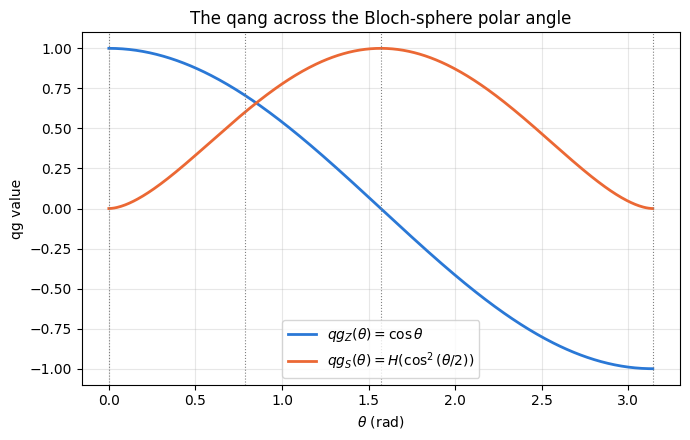

In [6]:
# --- qg_Z and qg_S across the full range of theta, and the gradient singularity ---
thetas = np.linspace(0, math.pi, 400)
qz = [Qang.from_angles(t, mode="polar").value for t in thetas]
qs = [Qang.from_angles(t, mode="entropic").value for t in thetas]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thetas, qz, label=r"$qg_Z(\theta) = \cos\theta$", linewidth=2, color="#2a78d6")
ax.plot(thetas, qs, label=r"$qg_S(\theta) = H(\cos^2(\theta/2))$", linewidth=2, color="#eb6834")
for name, theta in anchors:
    ax.axvline(theta, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel("qg value")
ax.set_title("The qang across the Bloch-sphere polar angle")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Explicit half-domain inversion of `qg_S`

Section 2.2 notes `qg_S(theta) = qg_S(pi - theta)` (so a single `qg_S` value does not
determine `theta` over the full domain) but doesn't give the invertible restriction
explicitly. `Qang.theta_from_entropic(qg_s, branch=...)` fills that gap: `qg_S` is
*strictly increasing* on `theta in [0, pi/2]` ("lower" branch) and *strictly decreasing*
on `theta in [pi/2, pi]` ("upper" branch) — each half is invertible on its own.


In [7]:
for theta in (0.3, 1.0, 1.4):
    s = Qang.from_angles(theta, mode="entropic").value
    recovered = Qang.theta_from_entropic(s, branch="lower")
    print(f"theta={theta:.4f}  qg_S={s:.4f}  recovered theta (lower branch)={recovered:.4f}")

for theta in (1.8, 2.2, 2.9):
    s = Qang.from_angles(theta, mode="entropic").value
    recovered = Qang.theta_from_entropic(s, branch="upper")
    print(f"theta={theta:.4f}  qg_S={s:.4f}  recovered theta (upper branch)={recovered:.4f}")

theta=0.3000  qg_S=0.1543  recovered theta (lower branch)=0.3000
theta=1.0000  qg_S=0.7777  recovered theta (lower branch)=1.0000
theta=1.4000  qg_S=0.9791  recovered theta (lower branch)=1.4000
theta=1.8000  qg_S=0.9624  recovered theta (upper branch)=1.8000
theta=2.2000  qg_S=0.7333  recovered theta (upper branch)=2.2000
theta=2.9000  qg_S=0.1095  recovered theta (upper branch)=2.9000


## 2. Section 4.1: the gradient singularity, regularized, and benchmarked

$$\frac{\partial E}{\partial (qg)} = \frac{\partial E}{\partial \theta} \cdot \frac{d\theta}{d(qg)} = -\frac{1}{\sin\theta}\cdot\frac{\partial E}{\partial \theta}$$

Since $d(qg_Z)/d\theta = -\sin\theta$, this **diverges exactly at the $\pm 1.0$ qg anchor
points** ($\theta = 0, \pi$). Two bounded alternatives to the exact inverse Jacobian are
implemented below (`inverse_jacobian_clipped`, `inverse_jacobian_tikhonov`), together with
a toy-VQE benchmark that starts an optimizer **at** a pole and compares theta-space,
raw qg-space, and both regularized qg-space variants.


In [8]:
from __future__ import annotations

import math
from dataclasses import dataclass, field
from typing import Callable, Dict, List


# --------------------------------------------------------------------- #
# Jacobian and its regularized inverses
# --------------------------------------------------------------------- #
def jacobian(theta: float) -> float:
    """d(qg_Z)/d(theta) = -sin(theta). Exact; vanishes at theta = 0, pi."""
    return -math.sin(theta)


def inverse_jacobian_raw(theta: float) -> float:
    """d(theta)/d(qg_Z) = -1/sin(theta). Exact; diverges at theta = 0, pi."""
    s = math.sin(theta)
    if abs(s) < 1e-12:
        return float("-inf")
    return -1.0 / s


def inverse_jacobian_clipped(theta: float, eps: float = 0.05) -> float:
    """
    Floor |sin(theta)| at eps before inverting. Bounded by 1/eps in
    magnitude; exact away from the poles.
    """
    s = math.sin(theta)
    s_floored = math.copysign(max(abs(s), eps), s if s != 0.0 else 1.0)
    return -1.0 / s_floored


def inverse_jacobian_tikhonov(theta: float, eps: float = 0.05) -> float:
    """
    Smooth Tikhonov-style regularization: -sin(theta) / (sin(theta)**2 + eps**2).
    Bounded and smooth everywhere, including exactly at theta = 0, pi (-> 0).
    """
    s = math.sin(theta)
    return -s / (s * s + eps * eps)


# --------------------------------------------------------------------- #
# Toy VQE loss: E(theta) = <psi(theta)| h_z*sigma_z + h_x*sigma_x |psi(theta)>
# for the real (phi=0) state |psi(theta)> = cos(theta/2)|0> + sin(theta/2)|1>,
# for which <sigma_z> = cos(theta) = qg_Z(theta) and <sigma_x> = sin(theta).
#
# Default h_z=0.0, h_x=-1.0 places the (unique, interior) minimum at
# theta = pi/2 -- deliberately far from both poles -- so that starting the
# optimizer AT a pole (theta0 near 0 or pi) is a genuine stress test of
# having to escape the coordinate singularity discussed in Section 4.1,
# rather than of a minimum that happens to sit at the domain boundary.
# --------------------------------------------------------------------- #
def toy_vqe_energy(theta: float, h_z: float = 0.0, h_x: float = -1.0) -> float:
    return h_z * math.cos(theta) + h_x * math.sin(theta)


def toy_vqe_grad_theta(theta: float, h_z: float = 0.0, h_x: float = -1.0) -> float:
    """dE/d(theta) for the toy Hamiltonian above."""
    return -h_z * math.sin(theta) + h_x * math.cos(theta)


# --------------------------------------------------------------------- #
# Gradient descent runner
# --------------------------------------------------------------------- #
@dataclass
class GDHistory:
    space: str
    theta: List[float] = field(default_factory=list)
    qg: List[float] = field(default_factory=list)
    energy: List[float] = field(default_factory=list)
    diverged: bool = False


def run_gradient_descent(
    space: str,
    theta0: float,
    lr: float = 0.05,
    steps: int = 200,
    eps: float = 0.05,
    h_z: float = 0.0,
    h_x: float = -1.0,
    grad_fn: Callable[[float, float, float], float] = toy_vqe_grad_theta,
    energy_fn: Callable[[float, float, float], float] = toy_vqe_energy,
) -> GDHistory:
    """
    Minimize energy_fn(theta) by gradient descent, parameterized either
    directly in theta-space, or in qg-space (raw or regularized).

    space : {"theta", "qg_raw", "qg_clipped", "qg_tikhonov"}
    """
    theta = float(theta0)
    hist = GDHistory(space=space)

    for _ in range(steps):
        theta = min(max(theta, 1e-9), math.pi - 1e-9)  # stay in the physical domain
        qg = math.cos(theta)
        e = energy_fn(theta, h_z, h_x)
        hist.theta.append(theta)
        hist.qg.append(qg)
        hist.energy.append(e)

        if not math.isfinite(e) or abs(theta) > 1e6:
            hist.diverged = True
            break

        dE_dtheta = grad_fn(theta, h_z, h_x)

        if space == "theta":
            theta = theta - lr * dE_dtheta
        else:
            if space == "qg_raw":
                dtheta_dqg = inverse_jacobian_raw(theta)
            elif space == "qg_clipped":
                dtheta_dqg = inverse_jacobian_clipped(theta, eps=eps)
            elif space == "qg_tikhonov":
                dtheta_dqg = inverse_jacobian_tikhonov(theta, eps=eps)
            else:
                raise ValueError(
                    "space must be one of 'theta', 'qg_raw', 'qg_clipped', 'qg_tikhonov'."
                )
            dE_dqg = dE_dtheta * dtheta_dqg
            new_qg = max(-1.0, min(1.0, qg - lr * dE_dqg))
            theta = math.acos(new_qg)

        if not math.isfinite(theta):
            hist.diverged = True
            break

    return hist


def benchmark(
    theta0: float = 0.05,
    lr: float = 0.05,
    steps: int = 200,
    eps: float = 0.05,
    h_z: float = 0.0,
    h_x: float = -1.0,
) -> Dict[str, GDHistory]:
    """Run all four optimization spaces from the same near-pole start point."""
    spaces = ["theta", "qg_raw", "qg_clipped", "qg_tikhonov"]
    return {
        s: run_gradient_descent(s, theta0, lr=lr, steps=steps, eps=eps, h_z=h_z, h_x=h_x)
        for s in spaces
    }

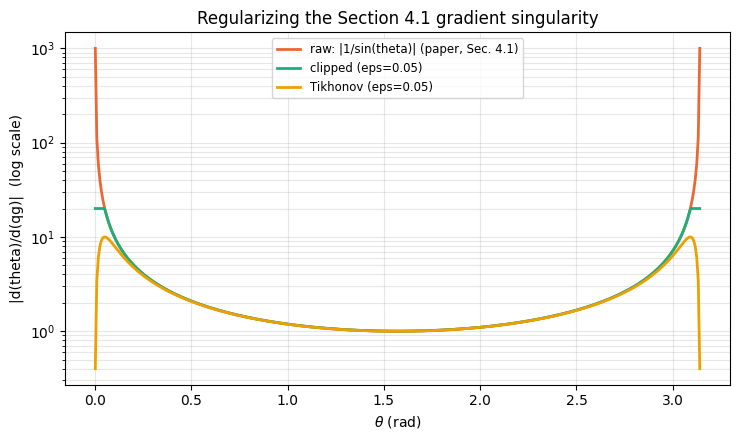

 theta (rad)   1/sin(theta)    clipped   tikhonov
      1.5708           1.00       1.00     0.9975
      0.7854           1.41       1.41     1.4072
      0.1000          10.02      10.02     8.0080
      0.0100         100.00      20.00     3.8461
      0.0010        1000.00      20.00     0.3998


In [9]:
thetas_fine = np.linspace(0.001, math.pi - 0.001, 400)
raw = [abs(inverse_jacobian_raw(t)) for t in thetas_fine]
clipped = [abs(inverse_jacobian_clipped(t, eps=0.05)) for t in thetas_fine]
tikhonov = [abs(inverse_jacobian_tikhonov(t, eps=0.05)) for t in thetas_fine]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(thetas_fine, raw, label="raw: |1/sin(theta)| (paper, Sec. 4.1)", color="#eb6834", linewidth=2)
ax.plot(thetas_fine, clipped, label="clipped (eps=0.05)", color="#1baf7a", linewidth=2)
ax.plot(thetas_fine, tikhonov, label="Tikhonov (eps=0.05)", color="#eda100", linewidth=2)
ax.set_yscale("log")
ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel("|d(theta)/d(qg)|  (log scale)")
ax.set_title("Regularizing the Section 4.1 gradient singularity")
ax.legend(fontsize=8.5)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print(f"{'theta (rad)':>12s} {'1/sin(theta)':>14s} {'clipped':>10s} {'tikhonov':>10s}")
for theta in [math.pi / 2, math.pi / 4, 0.1, 0.01, 0.001]:
    print(f"{theta:12.4f} {abs(inverse_jacobian_raw(theta)):14.2f} "
          f"{abs(inverse_jacobian_clipped(theta, 0.05)):10.2f} "
          f"{abs(inverse_jacobian_tikhonov(theta, 0.05)):10.4f}")

### Empirical benchmark

Toy loss $E(\theta) = -\sin(\theta)$, minimum at $\theta^* = \pi/2$ (deliberately far from
both poles). The optimizer starts **at** a pole, $\theta_0 = 0.01$ rad ($qg_Z \approx
0.9999$), so reaching the minimum requires escaping the singular region immediately.


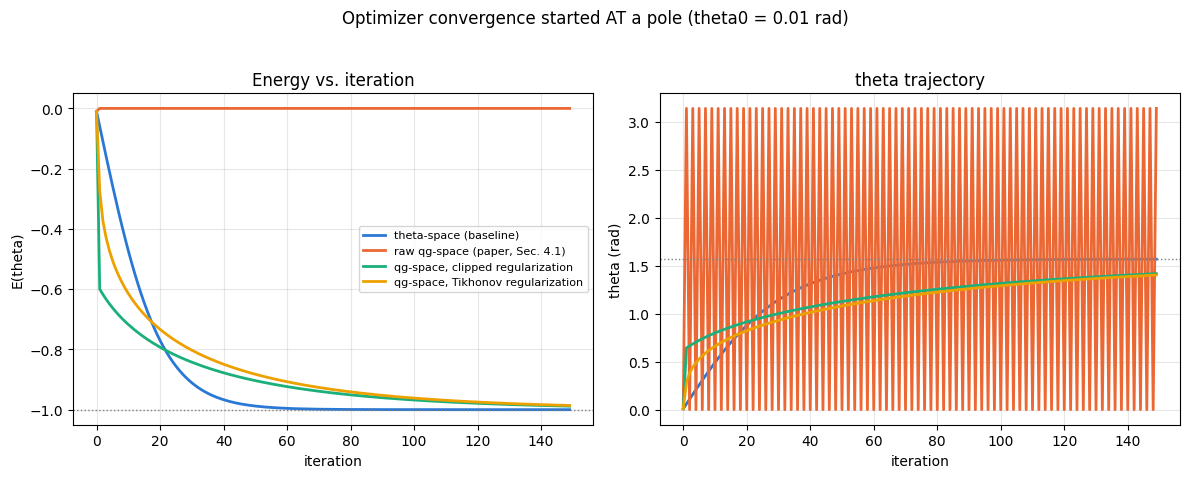


space             final theta    final E  |grad| final  max |step|
theta                  1.5698    -1.0000       0.00097      0.0500
qg_raw                 3.1416    -0.0000       1.00000      3.1416
qg_clipped             1.4184    -0.9884       0.15181      0.6336
qg_tikhonov            1.4043    -0.9862       0.16574      0.2684


In [10]:
LR = 0.05
STEPS = 150
THETA0 = 0.01
EPS = 0.05

results = {
    "theta": run_gradient_descent("theta", THETA0, lr=LR, steps=STEPS),
    "qg_raw": run_gradient_descent("qg_raw", THETA0, lr=LR, steps=STEPS),
    # regularized variants use a smaller lr, sized to their own step-size bound (~lr/eps)
    "qg_clipped": run_gradient_descent("qg_clipped", THETA0, lr=LR / 5, steps=STEPS, eps=EPS),
    "qg_tikhonov": run_gradient_descent("qg_tikhonov", THETA0, lr=LR / 5, steps=STEPS, eps=EPS),
}

LABELS = {
    "theta": "theta-space (baseline)",
    "qg_raw": "raw qg-space (paper, Sec. 4.1)",
    "qg_clipped": "qg-space, clipped regularization",
    "qg_tikhonov": "qg-space, Tikhonov regularization",
}
COLORS = {"theta": "#2a78d6", "qg_raw": "#eb6834", "qg_clipped": "#1baf7a", "qg_tikhonov": "#eda100"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for space in ["theta", "qg_raw", "qg_clipped", "qg_tikhonov"]:
    hist = results[space]
    it = list(range(len(hist.energy)))
    axes[0].plot(it, hist.energy, color=COLORS[space], linewidth=2, label=LABELS[space])
    axes[1].plot(it, hist.theta, color=COLORS[space], linewidth=2, label=LABELS[space])

axes[0].axhline(-1.0, color="gray", linestyle=":", linewidth=1)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("E(theta)"); axes[0].set_title("Energy vs. iteration")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].axhline(math.pi / 2, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("theta (rad)"); axes[1].set_title("theta trajectory")
axes[1].grid(alpha=0.3)

fig.suptitle("Optimizer convergence started AT a pole (theta0 = 0.01 rad)", y=1.03)
plt.tight_layout()
plt.show()

print(f"\n{'space':16s} {'final theta':>12s} {'final E':>10s} {'|grad| final':>13s} {'max |step|':>11s}")
for space in ["theta", "qg_raw", "qg_clipped", "qg_tikhonov"]:
    hist = results[space]
    steps_sizes = [abs(hist.theta[i + 1] - hist.theta[i]) for i in range(len(hist.theta) - 1)]
    max_step = max(steps_sizes) if steps_sizes else 0.0
    final_theta = hist.theta[-1]
    print(f"{space:16s} {final_theta:12.4f} {hist.energy[-1]:10.4f} "
          f"{abs(toy_vqe_grad_theta(final_theta)):13.5f} {max_step:11.4f}")

**Reading the result:** with the *same* learning rate as theta-space, raw qg-space
does not converge at all here — it overshoots straight past the target to the opposite
pole and oscillates between `theta ~ 0` and `theta ~ pi` for the whole run (this is a
sharper, empirical version of the paper's own qualitative warning in Section 4.1). Both
regularized variants converge, at the cost of a smaller learning rate.


## 3. Mixed states and POVMs (Future Research Direction #4, part 1)

> "extend the binary framework to POVMs and multi-outcome measurements, to mixed states
> (where, unlike the pure-state case treated here, the von Neumann entropy of rho is no
> longer trivially zero) ..."

`qg_Z` generalizes to **any** single-qubit state (pure or mixed) as `Tr(rho @ sigma_z)`.
The **von Neumann entropy** `S(rho) = -Tr(rho log2 rho)` is the quantity the paper's
Section 2.3 explicitly says `qg_S` is *not* — it fills that gap. And `qg_s_povm`
generalizes the measurement side to any n-outcome POVM, not just the two-outcome
Z-basis projection.


In [11]:
from __future__ import annotations

from typing import List, Sequence, Tuple

import numpy as np

SIGMA_X = np.array([[0, 1], [1, 0]], dtype=complex)
SIGMA_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
SIGMA_Z = np.array([[1, 0], [0, -1]], dtype=complex)
IDENTITY_2 = np.eye(2, dtype=complex)

PROJECT_0 = np.array([[1, 0], [0, 0]], dtype=complex)
PROJECT_1 = np.array([[0, 0], [0, 1]], dtype=complex)


# --------------------------------------------------------------------- #
# construction helpers
# --------------------------------------------------------------------- #
def density_from_statevector(psi: Sequence[complex]) -> np.ndarray:
    """rho = |psi><psi| for a (normalized) statevector of any dimension."""
    psi = np.asarray(psi, dtype=complex).reshape(-1, 1)
    norm = float(np.real((psi.conj().T @ psi)).item())
    if abs(norm - 1.0) > 1e-6:
        raise ValueError(f"statevector must be normalized, got norm={norm:.6f}.")
    return psi @ psi.conj().T


def mix(rho_a: np.ndarray, rho_b: np.ndarray, p: float) -> np.ndarray:
    """A classical (incoherent) mixture p*rho_a + (1-p)*rho_b."""
    if not (0.0 <= p <= 1.0):
        raise ValueError(f"p must lie in [0, 1], got {p}.")
    return p * np.asarray(rho_a, dtype=complex) + (1.0 - p) * np.asarray(rho_b, dtype=complex)


def is_valid_density_matrix(rho: np.ndarray, atol: float = 1e-6) -> bool:
    """Hermitian, unit trace, positive semi-definite."""
    rho = np.asarray(rho, dtype=complex)
    hermitian = np.allclose(rho, rho.conj().T, atol=atol)
    unit_trace = abs(np.trace(rho) - 1.0) < atol
    eigvals = np.linalg.eigvalsh((rho + rho.conj().T) / 2.0)
    psd = bool(np.all(eigvals >= -atol))
    return bool(hermitian and unit_trace and psd)


# --------------------------------------------------------------------- #
# polar qang for a general (pure or mixed) single-qubit state
# --------------------------------------------------------------------- #
def qg_z_density(rho: np.ndarray) -> float:
    """
    qg_Z for any single-qubit density matrix: Tr(rho @ sigma_z).

    For a pure state rho = |psi><psi| with |psi> = cos(theta/2)|0> +
    e^{i*phi} sin(theta/2)|1>, this reduces exactly to cos(theta), matching
    qang.core.Qang.from_angles(theta, mode="polar").value.
    """
    rho = np.asarray(rho, dtype=complex)
    if rho.shape != (2, 2):
        raise ValueError(f"qg_z_density expects a single-qubit (2x2) rho, got shape {rho.shape}.")
    return float(np.real(np.trace(rho @ SIGMA_Z)))


def purity(rho: np.ndarray) -> float:
    """Tr(rho^2); 1.0 for a pure state, 1/d for the maximally mixed state of dim d."""
    rho = np.asarray(rho, dtype=complex)
    return float(np.real(np.trace(rho @ rho)))


# --------------------------------------------------------------------- #
# von Neumann entropy -- the quantity qg_S in the paper explicitly is NOT
# --------------------------------------------------------------------- #
def von_neumann_entropy(rho: np.ndarray, base: float = 2.0, atol: float = 1e-12) -> float:
    """
    S(rho) = -Tr(rho log_base rho), computed from rho's eigenvalues.

    Identically 0 for any pure state (rank-1 rho); this is exactly the fact
    the paper's Section 2.2 uses to justify why qg_S is instead defined as
    the *classical* Shannon entropy of the measurement-outcome distribution.
    von_neumann_entropy is the quantity that fills the "mixed states" half
    of Future Research Direction #4.
    """
    rho = np.asarray(rho, dtype=complex)
    eigvals = np.linalg.eigvalsh((rho + rho.conj().T) / 2.0)
    eigvals = np.clip(np.real(eigvals), 0.0, 1.0)
    s = 0.0
    for lam in eigvals:
        if lam > atol:
            s -= lam * (np.log(lam) / np.log(base))
    return float(s)


# --------------------------------------------------------------------- #
# POVM generalization -- the "multi-outcome measurements" half of
# Future Research Direction #4
# --------------------------------------------------------------------- #
def standard_z_povm() -> List[np.ndarray]:
    """The two-outcome projective Z-basis POVM {|0><0|, |1><1|}."""
    return [PROJECT_0, PROJECT_1]


def is_valid_povm(elements: Sequence[np.ndarray], atol: float = 1e-6) -> bool:
    """Each element positive semi-definite and they sum to the identity."""
    total = sum(np.asarray(e, dtype=complex) for e in elements)
    dim = total.shape[0]
    if not np.allclose(total, np.eye(dim, dtype=complex), atol=atol):
        return False
    for e in elements:
        eigvals = np.linalg.eigvalsh((e + e.conj().T) / 2.0)
        if np.any(eigvals < -atol):
            return False
    return True


def povm_outcome_probabilities(rho: np.ndarray, povm: Sequence[np.ndarray]) -> List[float]:
    """p_i = Tr(rho @ E_i) for each POVM element E_i (Born's rule, generalized)."""
    rho = np.asarray(rho, dtype=complex)
    probs = [float(np.real(np.trace(rho @ np.asarray(e, dtype=complex)))) for e in povm]
    total = sum(probs)
    if abs(total - 1.0) > 1e-4:
        raise ValueError(f"POVM outcome probabilities must sum to 1, got {total:.6f}.")
    return [max(0.0, p) for p in probs]


def qg_s_povm(rho: np.ndarray, povm: Sequence[np.ndarray], normalize: bool = True) -> float:
    """
    Generalized entropic qang: the Shannon entropy of an n-outcome POVM
    measurement on rho. With ``povm=standard_z_povm()`` and a pure-state rho,
    this reduces exactly to qg_S(theta) from qang.core.

    normalize=True divides by log2(n_outcomes) so the result stays in
    [0, 1] regardless of how many outcomes the POVM has, matching qg_S's
    original [0, 1] range; normalize=False returns the raw Shannon entropy
    in bits (range [0, log2(n_outcomes)]).
    """
    probs = povm_outcome_probabilities(rho, povm)
    n = len(probs)
    h = 0.0
    for p in probs:
        if p > 1e-15:
            h -= p * np.log2(p)
    if normalize and n > 1:
        h = h / np.log2(n)
    return float(h)


def trine_povm() -> List[np.ndarray]:
    """
    A canonical 3-outcome (non-projective) single-qubit POVM: three
    equally-spaced rank-1 elements (2/3)|v_k><v_k| in the X-Z plane, used
    as a worked example of the n-outcome generalization beyond n=2.
    """
    elements = []
    for k in range(3):
        angle = 2.0 * np.pi * k / 3.0
        v = np.array([[np.cos(angle / 2.0)], [np.sin(angle / 2.0)]], dtype=complex)
        elements.append((2.0 / 3.0) * (v @ v.conj().T))
    return elements

In [12]:
def pure_state_density(theta, phi=0.0):
    q = Qang.from_angles(theta, phi=phi, mode="polar")
    alpha, beta = q.to_statevector()
    return density_from_statevector([alpha, beta])

# 1) qg_z_density reduces exactly to qg_Z for a pure state
for theta in (0.0, math.pi / 2, math.pi, math.pi / 4):
    rho = pure_state_density(theta)
    print(f"theta={theta:.4f}  qg_z_density={qg_z_density(rho):+.4f}  "
          f"(expected {Qang.from_angles(theta, mode='polar').value:+.4f})")

print()
# 2) the case qg_Z alone cannot distinguish: same qg_Z, very different entropy
rho_plus = pure_state_density(math.pi / 2)                        # pure |+>, qg_Z = 0
rho0, rho1 = pure_state_density(0.0), pure_state_density(math.pi)  # |0>, |1>
rho_mixed = mix(rho0, rho1, p=0.5)                                 # classical 50/50 mixture, qg_Z = 0 too

print(f"|+>            : qg_Z={qg_z_density(rho_plus):+.4f}  von Neumann S={von_neumann_entropy(rho_plus):.4f}  (pure -> 0)")
print(f"50/50 mix(0,1) : qg_Z={qg_z_density(rho_mixed):+.4f}  von Neumann S={von_neumann_entropy(rho_mixed):.4f}  (mixed -> 1)")
print("Same qg_Z, both pure-state theory (qg_S) blind to the difference -- von Neumann entropy tells them apart.")

print()
# 3) POVM generalization reduces exactly to qg_S on the standard Z-basis POVM
for theta in (0.0, math.pi / 2, math.pi, math.pi / 4):
    rho = pure_state_density(theta)
    got = qg_s_povm(rho, standard_z_povm(), normalize=True)
    expected = Qang.from_angles(theta, mode="entropic").value
    print(f"theta={theta:.4f}  qg_s_povm (Z-basis)={got:.4f}  (expected {expected:.4f})")

print()
# 4) a genuinely 3-outcome POVM (trine), which qg_S alone has no notion of
rho = pure_state_density(math.pi / 2)
print(f"3-outcome trine POVM on |+>: normalized entropy = {qg_s_povm(rho, trine_povm(), normalize=True):.4f} "
      f"(raw bits = {qg_s_povm(rho, trine_povm(), normalize=False):.4f}, log2(3) = {math.log2(3):.4f})")

theta=0.0000  qg_z_density=+1.0000  (expected +1.0000)
theta=1.5708  qg_z_density=+0.0000  (expected +0.0000)
theta=3.1416  qg_z_density=-1.0000  (expected -1.0000)
theta=0.7854  qg_z_density=+0.7071  (expected +0.7071)

|+>            : qg_Z=+0.0000  von Neumann S=0.0000  (pure -> 0)
50/50 mix(0,1) : qg_Z=+0.0000  von Neumann S=1.0000  (mixed -> 1)
Same qg_Z, both pure-state theory (qg_S) blind to the difference -- von Neumann entropy tells them apart.

theta=0.0000  qg_s_povm (Z-basis)=0.0000  (expected 0.0000)
theta=1.5708  qg_s_povm (Z-basis)=1.0000  (expected 1.0000)
theta=3.1416  qg_s_povm (Z-basis)=0.0000  (expected 0.0000)
theta=0.7854  qg_s_povm (Z-basis)=0.6009  (expected 0.6009)

3-outcome trine POVM on |+>: normalized entropy = 0.7285 (raw bits = 1.1547, log2(3) = 1.5850)


## 4. Multi-qubit tensor-product profiles (Future Research Direction #4, part 2)

> "... and to multi-qubit systems via tensor-product projection profiles."

Two generalizations, both reducing exactly to the single-qubit definitions at
`n_qubits = 1`: a **per-qubit local qang** (partial-trace each qubit out and report its
own `qg_Z` / `qg_S`), and a **joint qang** (the Shannon entropy of the full `2^n`
measurement outcome distribution). The Bell state is the concrete demonstration of why
both are needed together.


In [13]:
from __future__ import annotations

import string
from typing import List, Sequence, Union

import numpy as np



def _as_density(state: Union[np.ndarray, Sequence[complex]], n_qubits: int) -> np.ndarray:
    """Accept either a 2^n statevector or a 2^n x 2^n density matrix."""
    state = np.asarray(state, dtype=complex)
    dim = 2 ** n_qubits
    if state.ndim == 1:
        if state.shape[0] != dim:
            raise ValueError(f"statevector has dim {state.shape[0]}, expected {dim} for n_qubits={n_qubits}.")
        return density_from_statevector(state)
    if state.shape != (dim, dim):
        raise ValueError(f"density matrix has shape {state.shape}, expected {(dim, dim)} for n_qubits={n_qubits}.")
    return state


def product_state(single_qubit_states: Sequence[np.ndarray]) -> np.ndarray:
    """
    Tensor-product density matrix of n independent single-qubit density
    matrices (or 2-component statevectors, which are converted first).
    """
    rho = None
    for s in single_qubit_states:
        s = np.asarray(s, dtype=complex)
        r = density_from_statevector(s) if s.ndim == 1 else s
        rho = r if rho is None else np.kron(rho, r)
    return rho


def bell_state(kind: str = "phi_plus") -> np.ndarray:
    """
    One of the four 2-qubit Bell states, as a statevector in the
    |00>, |01>, |10>, |11> basis -- the standard worked example of maximal
    entanglement, used in tests to show the joint/marginal entropy gap.
    """
    s = 1.0 / np.sqrt(2.0)
    kinds = {
        "phi_plus": np.array([s, 0, 0, s], dtype=complex),
        "phi_minus": np.array([s, 0, 0, -s], dtype=complex),
        "psi_plus": np.array([0, s, s, 0], dtype=complex),
        "psi_minus": np.array([0, s, -s, 0], dtype=complex),
    }
    if kind not in kinds:
        raise ValueError(f"kind must be one of {list(kinds)}, got {kind!r}.")
    return kinds[kind]


# --------------------------------------------------------------------- #
# partial trace
# --------------------------------------------------------------------- #
def partial_trace(rho: np.ndarray, n_qubits: int, keep: Sequence[int]) -> np.ndarray:
    """
    Reduced density matrix on the qubits in ``keep`` (0-indexed), tracing
    out every other qubit. Standard einsum-based partial trace.
    """
    keep = sorted(keep)
    if any(k < 0 or k >= n_qubits for k in keep):
        raise ValueError(f"keep indices must lie in [0, {n_qubits - 1}], got {keep}.")
    trace_out = [i for i in range(n_qubits) if i not in keep]

    letters = string.ascii_lowercase
    if 2 * n_qubits > len(letters):
        raise ValueError("partial_trace supports at most 13 qubits with this implementation.")

    row_labels = list(letters[:n_qubits])
    col_labels = list(letters[n_qubits:2 * n_qubits])
    for i in trace_out:
        col_labels[i] = row_labels[i]  # repeated index => einsum sums (traces) over it

    in_sub = "".join(row_labels) + "".join(col_labels)
    out_sub = "".join(row_labels[i] for i in keep) + "".join(col_labels[i] for i in keep)

    rho_t = rho.reshape([2] * (2 * n_qubits))
    result = np.einsum(f"{in_sub}->{out_sub}", rho_t)
    d = 2 ** len(keep)
    return result.reshape(d, d)


# --------------------------------------------------------------------- #
# per-qubit local qang ("projection profile" across the register)
# --------------------------------------------------------------------- #
def per_qubit_qg_z(state: Union[np.ndarray, Sequence[complex]], n_qubits: int) -> List[float]:
    """qg_Z for each qubit's own reduced density matrix: a length-n_qubits profile."""
    rho = _as_density(state, n_qubits)
    return [qg_z_density(partial_trace(rho, n_qubits, keep=[i])) for i in range(n_qubits)]


def marginal_qg_s(state: Union[np.ndarray, Sequence[complex]], n_qubits: int) -> List[float]:
    """
    Classical (Z-basis outcome) qg_S for each qubit's own marginal: the
    same H(p0) formula as the single-qubit qg_S, applied to each qubit's
    reduced diagonal.
    """
    rho = _as_density(state, n_qubits)
    result = []
    for i in range(n_qubits):
        reduced = partial_trace(rho, n_qubits, keep=[i])
        p0 = float(np.real(reduced[0, 0]))
        p0 = min(max(p0, 0.0), 1.0)
        p1 = 1.0 - p0
        h = 0.0
        for p in (p0, p1):
            if p > 1e-15:
                h -= p * np.log2(p)
        result.append(h)
    return result


def marginal_von_neumann_entropy(
    state: Union[np.ndarray, Sequence[complex]], n_qubits: int
) -> List[float]:
    """
    von Neumann entropy of each qubit's own reduced density matrix. For a
    product state this is 0 for every qubit (each qubit is individually
    pure); for an entangled state (e.g. a Bell pair) it is > 0 even when
    the *global* state is exactly pure -- the standard entanglement witness.
    """
    rho = _as_density(state, n_qubits)
    return [von_neumann_entropy(partial_trace(rho, n_qubits, keep=[i])) for i in range(n_qubits)]


# --------------------------------------------------------------------- #
# joint (whole-register) qg_S
# --------------------------------------------------------------------- #
def joint_qg_s(
    state: Union[np.ndarray, Sequence[complex]], n_qubits: int, normalize: bool = True
) -> float:
    """
    Shannon entropy of the full 2^n computational-basis outcome
    distribution obtained by measuring every qubit in the Z basis --
    the direct multi-qubit generalization of the single-qubit qg_S.

    normalize=True divides by log2(2^n) = n_qubits so the result stays in
    [0, 1] regardless of register size, matching qg_S's original range;
    normalize=False returns the raw Shannon entropy in bits.
    """
    rho = _as_density(state, n_qubits)
    probs = np.clip(np.real(np.diag(rho)), 0.0, 1.0)
    h = 0.0
    for p in probs:
        if p > 1e-15:
            h -= p * np.log2(p)
    if normalize and n_qubits > 1:
        h = h / n_qubits
    return float(h)

In [14]:
# n_qubits=1 reduces exactly to the single-qubit definitions
psi_single = np.array(Qang.from_angles(math.pi / 3, mode="polar").to_statevector())
print("single-qubit reduction check:", per_qubit_qg_z(psi_single, n_qubits=1),
      "expected", [Qang.from_angles(math.pi / 3, mode="polar").value])

print()
# a product (unentangled) state: joint entropy is just the average of the marginals
psi0 = np.array(Qang.from_angles(0.0, mode="polar").to_statevector())          # |0>, deterministic
psi1 = np.array(Qang.from_angles(math.pi / 2, mode="polar").to_statevector())  # |+>, maximal uncertainty
rho_product = product_state([psi0, psi1])
print("product state |0> (x) |+>:")
print("  per-qubit qg_Z:", [f"{v:+.4f}" for v in per_qubit_qg_z(rho_product, n_qubits=2)])
print("  per-qubit qg_S:", [f"{v:.4f}" for v in marginal_qg_s(rho_product, n_qubits=2)])
print("  joint qg_S (normalized):", f"{joint_qg_s(rho_product, n_qubits=2):.4f}")

print()
# the entanglement witness: Bell state
psi_bell = bell_state("phi_plus")
print("Bell state |Phi+>:")
print("  per-qubit qg_Z          :", [f"{v:+.4f}" for v in per_qubit_qg_z(psi_bell, n_qubits=2)],
      " <- each qubit LOOKS maximally mixed on its own")
print("  marginal von Neumann S  :", [f"{v:.4f}" for v in marginal_von_neumann_entropy(psi_bell, n_qubits=2)],
      " <- each qubit individually carries 1 bit of entropy")
print("  joint qg_S (raw bits)   :", f"{joint_qg_s(psi_bell, n_qubits=2, normalize=False):.4f}",
      " <- yet the WHOLE 2-qubit state is exactly pure (0 bits as a 4x4 density matrix)")
print()
print("This combination -- every part maximally mixed, the whole exactly pure -- is")
print("impossible for any unentangled (product) state: the standard entanglement witness.")

single-qubit reduction check: [0.5000000000000002] expected [0.5000000000000001]

product state |0> (x) |+>:
  per-qubit qg_Z: ['+1.0000', '+0.0000']
  per-qubit qg_S: ['0.0000', '1.0000']
  joint qg_S (normalized): 0.5000

Bell state |Phi+>:
  per-qubit qg_Z          : ['+0.0000', '+0.0000']  <- each qubit LOOKS maximally mixed on its own
  marginal von Neumann S  : ['1.0000', '1.0000']  <- each qubit individually carries 1 bit of entropy
  joint qg_S (raw bits)   : 1.0000  <- yet the WHOLE 2-qubit state is exactly pure (0 bits as a 4x4 density matrix)

This combination -- every part maximally mixed, the whole exactly pure -- is
impossible for any unentangled (product) state: the standard entanglement witness.


## 5. `qg` as a native Qiskit gate (Future Research Direction #1)

> "implement qg as a native unit/type in quantum-computing SDKs (Qiskit, Cirq, PennyLane
> wrappers), so that circuit parameters ... can be constructed, converted, and displayed
> natively in qg / m-qg rather than requiring manual trigonometric conversion at each call
> site."

`RQangGate` (qg_Z only, decomposes to `RY`) and `FullRQangGate` (full `(qg_Z, phi)`,
decomposes to the native `U(theta, phi, 0)` gate) consolidate the two gate designs from
the exploratory notebook into one clean, tested pair.


In [15]:
from qiskit.circuit import Gate, QuantumCircuit
from qiskit.circuit.library import RYGate, UGate
from qiskit import transpile
from qiskit_aer import AerSimulator


class RQangGate(Gate):
    """A single-qubit gate parameterized directly by qg_Z (polar qang).

    Prepares P(|0>) = (1 + qg_Z) / 2, P(|1>) = (1 - qg_Z) / 2 starting
    from |0>, with no control over the relative phase (equivalent to
    RY(theta) with theta = arccos(qg_Z)).
    """

    def __init__(self, qang_val, label: str = "RQang"):
        qg = qang_val if isinstance(qang_val, Qang) else Qang(qang_val, mode="polar")
        if qg.mode != "polar":
            raise ValueError("RQangGate requires a polar-mode Qang (qg_Z).")
        self._theta = qg.to_theta()
        super().__init__(name="rqang", num_qubits=1, params=[qg.value], label=label)

    def _define(self):
        qc = QuantumCircuit(1, name=self.name)
        qc.append(RYGate(self._theta), [0])
        self.definition = qc


class FullRQangGate(Gate):
    """A single-qubit gate parameterized by the full (qg_Z, phi) Bloch-sphere
    Qang, i.e. it prepares exactly the state Qang.to_statevector() describes,
    starting from |0>.
    """

    def __init__(self, qang: "Qang", label: str = "RQang3D"):
        if qang.mode != "polar":
            raise ValueError("FullRQangGate requires a polar-mode Qang (qg_Z, phi).")
        self.qang = qang
        theta, phi = qang.to_angles(unit="rad")
        self._theta = theta
        self._phi = phi
        super().__init__(name="rqang_3d", num_qubits=1, params=[qang.value, phi], label=label)

    def _define(self):
        qc = QuantumCircuit(1, name=self.name)
        # U(theta, phi, lambda=0)|0> = cos(theta/2)|0> + e^{i*phi} sin(theta/2)|1>
        qc.append(UGate(self._theta, self._phi, 0.0), [0])
        self.definition = qc


def append_qang(qc, qang, qubit: int, full: bool = True):
    """Convenience: append the right gate for `qang` to `qubit` of `qc`."""
    gate = FullRQangGate(qang) if full else RQangGate(qang)
    qc.append(gate, [qubit])
    return qc


In [16]:
# 1) RQangGate: prepare P(|0>), P(|1>) directly from a qg_Z value, no manual arccos
qg_target = Qang(0.5, mode="polar")
print(f"target: {qg_target}   expected probabilities: {qg_target.to_probabilities()}")

qc = QuantumCircuit(1, 1)
qc.append(RQangGate(qg_target), [0])
qc.measure(0, 0)
print(qc.draw(output="text"))

sim = AerSimulator()
counts = sim.run(transpile(qc, sim), shots=10000).result().get_counts()
p0_meas = counts.get("0", 0) / 10000
p1_meas = counts.get("1", 0) / 10000
print("measured:", counts, " -> reconstructed qg_Z:", Qang.from_probability(p0_meas, p1_meas))

target: Qang(+0.5000 qg_Z, φ=0.0°)   expected probabilities: (0.75, 0.25)
     ┌────────────┐┌─┐
  q: ┤ RQang(0.5) ├┤M├
     └────────────┘└╥┘
c: 1/═══════════════╩═
                    0 
measured: {'0': 7521, '1': 2479}  -> reconstructed qg_Z: Qang(+0.5042 qg_Z, φ=0.0°)


In [17]:
# 2) FullRQangGate: full (qg_Z, phi) state prep, e.g. |+i> = (|0> + i|1>)/sqrt(2)
qg_full = Qang.from_angles(theta=math.pi / 2, phi=math.pi / 2, mode="polar")
print(f"target: {qg_full}")

qc2 = QuantumCircuit(1, 1)
qc2.append(FullRQangGate(qg_full), [0])
qc2.measure(0, 0)

counts2 = sim.run(transpile(qc2, sim), shots=10000).result().get_counts()
print("Z-basis measurement counts (expect ~50/50):", counts2)

target: Qang(+0.0000 qg_Z, φ=90.0°)
Z-basis measurement counts (expect ~50/50): {'1': 4940, '0': 5060}


## 6. Shot-noise error propagation between probability-space and theta/qg-space (Future Research Direction #2)

> "prove the stated bounds, the domain over which qg_Z and qg_S are each invertible ...
> and error-propagation bounds when converting between theta-space and qg-space ..."

You never observe $P(|0\rangle)$ directly — you estimate it from $N$ measurement shots as
$\hat{p}_0 = \text{counts}_0 / N$, a $\text{Binomial}(N, p_0)/N$ estimator with
$\text{Var}(\hat{p}_0) = p_0(1-p_0)/N$. Since $\hat{qg}_Z = 2\hat{p}_0 - 1$, that shot noise
propagates into $\hat{qg}_Z$, and then — through the *same* singular Jacobian from Section 2
above — into $\hat{\theta} = \arccos(\hat{qg}_Z)$.

**Closed form (delta method, first order):**

$$\text{Var}(\hat{qg}_Z) = \frac{4\,p_0(1-p_0)}{N} = \frac{\sin^2\theta}{N} \qquad
\text{Var}(\hat{\theta}) \approx \text{Var}(\hat{qg}_Z)\cdot\left(\frac{d\theta}{d(qg)}\right)^2
= \frac{\sin^2\theta}{N}\cdot\frac{1}{\sin^2\theta} = \frac{1}{N}$$

The $\sin^2\theta$ factors **cancel exactly** — to first order, the propagated angular
uncertainty is *constant* ($\text{std} \approx 1/\sqrt{N}$ rad) across the whole Bloch
sphere, independent of $\theta$: the shrinking shot-noise variance near a pole (fewer
"wrong-outcome" events to see) exactly offsets the growing sensitivity of $\arccos$ there
(the Section 2 / paper-Section-4.1 singularity). This is a genuinely different statement
from the *optimization*-step story in Section 2: there, the energy gradient does **not**
shrink near a pole, so a qg-space gradient *step* still needs regularizing even though
qg-space *measurement* uncertainty self-regularizes. The cancellation is only first-order,
though: very close to a pole with few shots, the minority outcome becomes a rare event and
the Gaussian approximation breaks down (demonstrated below).


In [18]:
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import List, Optional



# --------------------------------------------------------------------- #
# closed-form (delta-method) propagation
# --------------------------------------------------------------------- #
def p0_from_theta(theta: float) -> float:
    return math.cos(theta / 2.0) ** 2


def var_qg_z_shot_noise(theta: float, n_shots: int) -> float:
    """
    Var(qg_Z_hat) for N i.i.d. Z-basis measurement shots on the state at
    polar angle theta. Exact (not an approximation): Var(qg_Z_hat) =
    4*p0*(1-p0)/N = sin^2(theta)/N.
    """
    if n_shots <= 0:
        raise ValueError(f"n_shots must be positive, got {n_shots}.")
    p0 = p0_from_theta(theta)
    return 4.0 * p0 * (1.0 - p0) / n_shots


def std_qg_z_shot_noise(theta: float, n_shots: int) -> float:
    return math.sqrt(var_qg_z_shot_noise(theta, n_shots))


def propagated_theta_variance(theta: float, n_shots: int) -> float:
    """
    First-order (delta-method) propagated variance of theta_hat =
    arccos(qg_Z_hat), reusing the exact inverse Jacobian from
    qang.gradients (the same -1/sin(theta) that diverges at the poles in
    the *optimization* story). Away from the poles this evaluates to
    (very nearly) 1/n_shots for ANY theta -- see the module docstring for
    why the sin^2(theta) factors cancel.
    """
    var_qg = var_qg_z_shot_noise(theta, n_shots)
    dtheta_dqg = inverse_jacobian_raw(theta)
    if not math.isfinite(dtheta_dqg):
        return float("inf")  # exactly at a pole: linear approximation breaks down (0 * inf)
    return var_qg * dtheta_dqg ** 2


def propagated_theta_std(theta: float, n_shots: int) -> float:
    var = propagated_theta_variance(theta, n_shots)
    return math.sqrt(var) if math.isfinite(var) else float("inf")


def confidence_interval_theta(
    theta_hat: float, n_shots: int, confidence: float = 0.95
) -> tuple:
    """
    A normal-approximation confidence interval for the true theta, centered
    on an observed theta_hat, using the (theta-independent, away from the
    poles) 1/n_shots propagated variance: CI = theta_hat +/- z * sqrt(1/N).
    z=1.96 for confidence=0.95.
    """
    z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_scores.get(round(confidence, 2))
    if z is None:
        raise ValueError(f"confidence must be one of {sorted(z_scores)}, got {confidence}.")
    half_width = z / math.sqrt(n_shots)
    lo = max(0.0, theta_hat - half_width)
    hi = min(math.pi, theta_hat + half_width)
    return lo, hi


# --------------------------------------------------------------------- #
# empirical validation via simulated measurement (Qiskit AerSimulator)
# --------------------------------------------------------------------- #
@dataclass
class BootstrapResult:
    theta: float
    n_shots: int
    n_trials: int
    theta_hat_samples: List[float]
    empirical_mean: float
    empirical_std: float
    analytical_std: float
    n_at_pole_boundary: int  # trials where theta_hat landed exactly on a domain boundary (0 or pi)


def empirical_theta_std(
    theta: float,
    n_shots: int,
    n_trials: int = 500,
    seed: Optional[int] = None,
) -> BootstrapResult:
    """
    Simulate n_trials independent experiments, each measuring the qg_Z
    state at polar angle `theta` with `n_shots` shots on Qiskit's
    AerSimulator, reconstructing theta_hat = arccos(qg_Z_hat) each time,
    and returning the empirical mean/std of theta_hat across trials --
    for direct comparison against propagated_theta_std(theta, n_shots).

    Requires Qiskit + qiskit-aer (raises ImportError with an install hint
    if unavailable, same pattern as qang.qiskit_gate).
    """
    try:
        from qiskit import QuantumCircuit, transpile
        from qiskit_aer import AerSimulator
    except ImportError as exc:  # pragma: no cover
        raise ImportError(
            "qang.statistics.empirical_theta_std requires Qiskit + qiskit-aer. "
            "Install with `pip install qiskit qiskit-aer`."
        ) from exc


    qg = Qang.from_angles(theta, mode="polar")
    qc = QuantumCircuit(1, 1)
    qc.append(RQangGate(qg), [0])
    qc.measure(0, 0)

    sim = AerSimulator(seed_simulator=seed)
    qc_t = transpile(qc, sim)

    theta_hats: List[float] = []
    at_boundary = 0
    for trial in range(n_trials):
        trial_seed = None if seed is None else seed + trial
        job = sim.run(qc_t, shots=n_shots, seed_simulator=trial_seed)
        counts = job.result().get_counts()
        p0_hat = counts.get("0", 0) / n_shots
        p1_hat = counts.get("1", 0) / n_shots
        qg_hat = max(-1.0, min(1.0, p0_hat - p1_hat))
        theta_hat = math.acos(qg_hat)
        theta_hats.append(theta_hat)
        if qg_hat <= -1.0 + 1e-12 or qg_hat >= 1.0 - 1e-12:
            at_boundary += 1

    mean_theta = sum(theta_hats) / len(theta_hats)
    var_theta = sum((t - mean_theta) ** 2 for t in theta_hats) / (len(theta_hats) - 1)

    return BootstrapResult(
        theta=theta,
        n_shots=n_shots,
        n_trials=n_trials,
        theta_hat_samples=theta_hats,
        empirical_mean=mean_theta,
        empirical_std=math.sqrt(var_theta),
        analytical_std=propagated_theta_std(theta, n_shots),
        n_at_pole_boundary=at_boundary,
    )

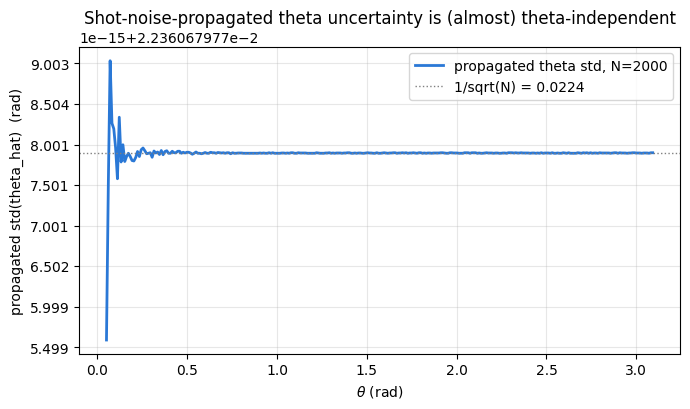

   theta   analytical std
  0.3000         0.022361
  1.0000         0.022361
  1.5708         0.022361
  2.2000         0.022361
  2.9000         0.022361


In [19]:
# --- the propagated theta std is (almost) theta-independent, away from the poles ---
thetas_demo = np.linspace(0.05, math.pi - 0.05, 300)
n_shots_demo = 2000
prop_std = [propagated_theta_std(t, n_shots_demo) for t in thetas_demo]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(thetas_demo, prop_std, color="#2a78d6", linewidth=2, label=f"propagated theta std, N={n_shots_demo}")
ax.axhline(1 / math.sqrt(n_shots_demo), color="gray", linestyle=":", linewidth=1,
           label=f"1/sqrt(N) = {1 / math.sqrt(n_shots_demo):.4f}")
ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel("propagated std(theta_hat)  (rad)")
ax.set_title("Shot-noise-propagated theta uncertainty is (almost) theta-independent")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'theta':>8s} {'analytical std':>16s}")
for t in [0.3, 1.0, math.pi / 2, 2.2, 2.9]:
    print(f"{t:8.4f} {propagated_theta_std(t, n_shots_demo):16.6f}")

In [20]:
# --- empirical validation on Qiskit's AerSimulator, away from a pole ---
result_mid = empirical_theta_std(theta=math.pi / 2, n_shots=2000, n_trials=300, seed=42)
print(f"theta=pi/2, N=2000 shots, 300 trials:")
print(f"  analytical std = {result_mid.analytical_std:.5f} rad")
print(f"  empirical std  = {result_mid.empirical_std:.5f} rad")
print(f"  empirical mean = {result_mid.empirical_mean:.5f} rad  (target {math.pi / 2:.5f})")
print(f"  trials at a pole boundary: {result_mid.n_at_pole_boundary}/{result_mid.n_trials}")

print()
# --- and the breakdown VERY close to a pole: with few shots, many trials land EXACTLY on the pole ---
result_pole = empirical_theta_std(theta=0.05, n_shots=50, n_trials=300, seed=7)
print(f"theta=0.05 (near the north pole), N=50 shots, 300 trials:")
print(f"  analytical std (delta-method) = {result_pole.analytical_std:.5f} rad")
print(f"  empirical std                 = {result_pole.empirical_std:.5f} rad")
print(f"  trials at a pole boundary: {result_pole.n_at_pole_boundary}/{result_pole.n_trials}"
      "  <- the Gaussian delta-method approximation is not a good description here")

theta=pi/2, N=2000 shots, 300 trials:
  analytical std = 0.02236 rad
  empirical std  = 0.02388 rad
  empirical mean = 1.57087 rad  (target 1.57080)
  trials at a pole boundary: 0/300



theta=0.05 (near the north pole), N=50 shots, 300 trials:
  analytical std (delta-method) = 0.14142 rad
  empirical std                 = 0.05570 rad
  trials at a pole boundary: 288/300  <- the Gaussian delta-method approximation is not a good description here


### A practical confidence interval

In [21]:
theta_hat = 1.0
for n in (1000, 10000, 100000):
    lo, hi = confidence_interval_theta(theta_hat, n_shots=n, confidence=0.95)
    print(f"N={n:>7d} shots -> 95% CI for theta given theta_hat={theta_hat}: "
          f"[{lo:.4f}, {hi:.4f}] rad (half-width {hi - theta_hat:.4f} rad)")

N=   1000 shots -> 95% CI for theta given theta_hat=1.0: [0.9380, 1.0620] rad (half-width 0.0620 rad)
N=  10000 shots -> 95% CI for theta given theta_hat=1.0: [0.9804, 1.0196] rad (half-width 0.0196 rad)
N= 100000 shots -> 95% CI for theta given theta_hat=1.0: [0.9938, 1.0062] rad (half-width 0.0062 rad)


## 7. `qg` as a native Cirq gate (Future Research Direction #1, second SDK)

The same gate integration as Section 5, now for Cirq. `rqang_gate` uses Cirq's own native
`cirq.ry(theta)` directly (no custom `Gate` subclass needed for the qg_Z-only case);
`full_rqang_gate` wraps an explicit `U(theta, phi, lambda=0)` unitary in `cirq.MatrixGate`,
using the **same convention as Qiskit's `UGate`** above, so a `Qang` prepares bit-for-bit
the same state on either SDK.


In [22]:
import cirq


def rqang_gate(qang_val):
    """qg_Z-only preparation: Cirq's native ry(theta) IS the right primitive here."""
    qg = qang_val if isinstance(qang_val, Qang) else Qang(qang_val, mode="polar")
    if qg.mode != "polar":
        raise ValueError("rqang_gate requires a polar-mode Qang (qg_Z).")
    return cirq.ry(qg.to_theta())


def full_rqang_gate(qang: "Qang"):
    """Full (qg_Z, phi) Bloch-sphere preparation, as an explicit 2x2 unitary
    (U(theta, phi, lambda=0), same convention as Qiskit's UGate) wrapped in
    cirq.MatrixGate -- matches FullRQangGate above bit-for-bit."""
    if qang.mode != "polar":
        raise ValueError("full_rqang_gate requires a polar-mode Qang (qg_Z, phi).")
    theta, phi = qang.to_angles(unit="rad")
    c, s = math.cos(theta / 2.0), math.sin(theta / 2.0)
    phase = cmath.exp(1j * phi)
    matrix = np.array([[c, -s], [phase * s, phase * c]], dtype=complex)
    return cirq.MatrixGate(matrix, name=f"RQang3D({qang.value:+.4f},{phi:.4f})")


def append_qang(circuit, qang, qubit, full: bool = True):
    """Convenience: append the right gate for `qang` to `qubit` of `circuit`."""
    gate = full_rqang_gate(qang) if full else rqang_gate(qang)
    circuit.append(gate.on(qubit))
    return circuit


In [23]:
# 1) rqang_gate: prepare P(|0>), P(|1>) directly from a qg_Z value, same target as Section 5
qg_target_cirq = Qang(0.5, mode="polar")
print(f"target: {qg_target_cirq}   expected probabilities: {qg_target_cirq.to_probabilities()}")

q = cirq.LineQubit(0)
circuit = cirq.Circuit([rqang_gate(qg_target_cirq).on(q), cirq.measure(q, key="m")])
print(circuit)

csim = cirq.Simulator()
res = csim.run(circuit, repetitions=10000)
counts = res.histogram(key="m")
p0_meas = counts.get(0, 0) / 10000
p1_meas = counts.get(1, 0) / 10000
print("measured:", dict(counts), " -> reconstructed qg_Z:", Qang.from_probability(p0_meas, p1_meas))

target: Qang(+0.5000 qg_Z, φ=0.0°)   expected probabilities: (0.75, 0.25)
0: ───Ry(0.333π)───M('m')───
measured: {1: 2489, 0: 7511}  -> reconstructed qg_Z: Qang(+0.5022 qg_Z, φ=0.0°)


In [24]:
# 2) full_rqang_gate: full (qg_Z, phi) state prep, e.g. |+i> = (|0> + i|1>)/sqrt(2) -- same target as Section 5
qg_full_cirq = Qang.from_angles(theta=math.pi / 2, phi=math.pi / 2, mode="polar")
print(f"target: {qg_full_cirq}")

circuit2 = cirq.Circuit([full_rqang_gate(qg_full_cirq).on(q), cirq.measure(q, key="m")])
res2 = csim.run(circuit2, repetitions=10000)
counts2 = res2.histogram(key="m")
print("Z-basis measurement counts (expect ~50/50):", dict(counts2))

# cross-check: Cirq's prepared statevector should match Qang.to_statevector() exactly (up to global phase)
sv_result = csim.simulate(cirq.Circuit([full_rqang_gate(qg_full_cirq).on(q)]))
got = sv_result.final_state_vector
expected = np.array(qg_full_cirq.to_statevector())
overlap = abs(np.vdot(expected, got)) ** 2
print(f"Cirq vs. Qang.to_statevector() fidelity |<expected|got>|^2 = {overlap:.6f}  (expect 1.0)")

target: Qang(+0.0000 qg_Z, φ=90.0°)
Z-basis measurement counts (expect ~50/50): {0: 4890, 1: 5110}
Cirq vs. Qang.to_statevector() fidelity |<expected|got>|^2 = 1.000000  (expect 1.0)


## 8. Quantum Natural Gradient (QNG): completing the Section 4.1 / Direction #3 comparison

> "Characterization of qang gradients: study and, where possible, regularize the
> coordinate singularity at θ = 0, π identified in Section 4.1, **and compare the
> convergence behavior of qg-space optimization against standard θ-space
> parameterization and quantum natural gradient methods.**"

Section 2 regularizes the raw qg-space Jacobian with two *ad hoc* fixes (`eps`-clipping,
Tikhonov damping) -- both work, but both need a hand-tuned `eps` and, empirically, a
smaller learning rate to stay stable. This section derives the metric that is actually
*responsible* for the singularity -- the Fubini-Study metric, i.e. the quantum Fisher
information (QFI) -- and shows that preconditioning the qg-space gradient by its inverse
(the quantum natural gradient of Stokes, Izaac, Killoran & Carleo, 2020 -- already
reference [4] of the paper) cancels the divergence *exactly*, with no `eps` and no
reduced learning rate. This is the comparison Direction #3 asks for that Section 2 does
not yet provide.


For the real single-qubit rotation $|\psi(\theta)\rangle = \cos(\theta/2)|0\rangle +
\sin(\theta/2)|1\rangle$, the quantum Fisher information with respect to $\theta$ is the
textbook constant result $F_Q(\theta) = 1$ (Stokes et al. 2020), so the Fubini-Study line
element is

$$ds^2 = \tfrac{1}{4} F_Q(\theta)\, d\theta^2 = \tfrac{1}{4}\, d\theta^2 .$$

Changing coordinates to $qg_Z = \cos\theta$ (so $d(qg_Z) = -\sin\theta \, d\theta$) pulls
this metric back to qg-space:

$$ds^2 = \frac{1}{4\,(1 - qg_Z^2)}\, d(qg_Z)^2
\quad\Longrightarrow\quad
F_Q(qg_Z) = \frac{1}{1 - qg_Z^2}.$$

$F_Q(qg_Z)$ diverges at $qg_Z = \pm 1$ -- **exactly** the same $1/\sin\theta$ singularity
identified in Section 4.1 of the paper, now recognized as genuine curvature rather than
an artifact of the coordinate choice: the qg-space label $\pm 1.0$ really does sit
infinitely far away, in the information-geometry sense, from any interior point. Its
inverse,

$$F_Q(qg_Z)^{-1} = 1 - qg_Z^2 = \sin^2\theta,$$

is bounded on all of $[-1, 1]$ and vanishes exactly at the poles -- and using precisely
this as a preconditioner on the raw qg-space gradient is the natural-gradient step
implemented below.


In [ ]:
def qfi_qang(qg_val: float) -> float:
    """Quantum Fisher Information (Fubini-Study metric) pulled back to qg-space:

        F_Q(qg) = 1 / (1 - qg^2)

    Diverges exactly at the poles |qg| = 1 -- by construction this is the *same*
    metric responsible for the 1/sin(theta) singularity in Section 4.1, not a new
    problem introduced here."""
    denom = 1.0 - qg_val ** 2
    if denom <= 0.0:
        return float("inf")
    return 1.0 / denom


def qfi_inverse_qg(qg_val: float) -> float:
    """[F_Q(qg)]^{-1} = 1 - qg^2. Bounded on all of [-1, 1], zero exactly at the poles.
    This is what preconditions the natural-gradient step below, and it is what makes
    that step finite starting exactly AT a pole -- no eps required."""
    return max(0.0, 1.0 - qg_val ** 2)


# --- sanity checks -------------------------------------------------
assert math.isclose(qfi_qang(0.0), 1.0)
assert qfi_qang(1.0) == float("inf")
assert math.isclose(qfi_inverse_qg(0.0), 1.0)
assert qfi_inverse_qg(1.0) == 0.0
print(f"F_Q(qg=0.00) = {qfi_qang(0.0):.4f}   (equator: flat, matches theta-space)")
print(f"F_Q(qg=0.90) = {qfi_qang(0.9):.4f}")
print(f"F_Q(qg=0.99) = {qfi_qang(0.99):.4f}  (blowing up near the pole)")
print(f"F_Q(qg=1.00) = {qfi_qang(1.0)}       (diverges exactly at the pole, cf. Sec. 4.1)")


In [ ]:
def run_qng_descent(
    theta0: float,
    lr: float = 0.05,
    steps: int = 200,
    h_z: float = 0.0,
    h_x: float = -1.0,
) -> GDHistory:
    """
    Quantum Natural Gradient descent in qg-space. Reuses GDHistory, toy_vqe_energy,
    toy_vqe_grad_theta and inverse_jacobian_raw from Section 2 unchanged -- the only
    new ingredient is preconditioning the *exact* qg-space gradient by
    [F_Q(qg)]^{-1} = 1 - qg^2 (`qfi_inverse_qg`) before taking the step:

        dE/d(qg)_exact = dE/d(theta) * (d(theta)/d(qg))_exact   # Section 2's exact Jacobian
        step           = lr * [F_Q(qg)]^{-1} * dE/d(qg)_exact   # natural-gradient step

    Because [F_Q]^{-1} vanishes exactly where the raw Jacobian diverges, the product
    stays finite everywhere on [-1, 1], including starting exactly at theta0 -> 0.
    """
    theta = float(theta0)
    hist = GDHistory(space="qg_qng")

    for _ in range(steps):
        theta = min(max(theta, 1e-9), math.pi - 1e-9)
        qg = math.cos(theta)
        e = toy_vqe_energy(theta, h_z, h_x)
        hist.theta.append(theta)
        hist.qg.append(qg)
        hist.energy.append(e)

        if not math.isfinite(e):
            hist.diverged = True
            break

        dE_dtheta = toy_vqe_grad_theta(theta, h_z, h_x)
        dE_dqg_exact = dE_dtheta * inverse_jacobian_raw(theta)     # Section 2, unregularized
        natural_dE_dqg = qfi_inverse_qg(qg) * dE_dqg_exact         # precondition by F_Q^{-1}
        new_qg = max(-1.0, min(1.0, qg - lr * natural_dE_dqg))
        theta = math.acos(new_qg)

        if not math.isfinite(theta):
            hist.diverged = True
            break

    return hist


### Empirical benchmark: same setup as Section 2, QNG added at the *same* learning rate

Same toy loss, same pole start ($\theta_0 = 0.01$ rad), same `LR` as the theta-space
baseline -- deliberately **not** the reduced learning rate that `qg_clipped` and
`qg_tikhonov` needed for stability.


In [ ]:
LR = 0.05
STEPS = 150
THETA0 = 0.01
EPS = 0.05

results_s8 = {
    "theta": run_gradient_descent("theta", THETA0, lr=LR, steps=STEPS),
    "qg_raw": run_gradient_descent("qg_raw", THETA0, lr=LR, steps=STEPS),
    "qg_clipped": run_gradient_descent("qg_clipped", THETA0, lr=LR / 5, steps=STEPS, eps=EPS),
    "qg_tikhonov": run_gradient_descent("qg_tikhonov", THETA0, lr=LR / 5, steps=STEPS, eps=EPS),
    "qg_qng": run_qng_descent(THETA0, lr=LR, steps=STEPS),
}

LR_USED = {"theta": LR, "qg_raw": LR, "qg_clipped": LR / 5, "qg_tikhonov": LR / 5, "qg_qng": LR}
LABELS_S8 = {
    "theta": "theta-space (baseline)",
    "qg_raw": "raw qg-space (paper, Sec. 4.1)",
    "qg_clipped": "qg-space, clipped (Sec. 2)",
    "qg_tikhonov": "qg-space, Tikhonov (Sec. 2)",
    "qg_qng": "QNG in qg-space (Sec. 8, same lr as baseline)",
}
COLORS_S8 = {
    "theta": "#2a78d6", "qg_raw": "#eb6834", "qg_clipped": "#1baf7a",
    "qg_tikhonov": "#eda100", "qg_qng": "#8e44ad",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for space in ["theta", "qg_raw", "qg_clipped", "qg_tikhonov", "qg_qng"]:
    hist = results_s8[space]
    it = list(range(len(hist.energy)))
    axes[0].plot(it, hist.energy, color=COLORS_S8[space], linewidth=2, label=LABELS_S8[space])
    axes[1].plot(it, hist.theta, color=COLORS_S8[space], linewidth=2, label=LABELS_S8[space])

axes[0].axhline(-1.0, color="gray", linestyle=":", linewidth=1)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("E(theta)")
axes[0].set_title("Energy vs. iteration (QNG added)")
axes[0].legend(fontsize=7.5); axes[0].grid(alpha=0.3)

axes[1].axhline(math.pi / 2, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("theta (rad)")
axes[1].set_title("theta trajectory (QNG added)")
axes[1].grid(alpha=0.3)

fig.suptitle("Section 8: QNG matches the theta-space baseline, same lr, no eps", y=1.03)
plt.tight_layout()
plt.show()

print(f"\n{'space':16s} {'lr used':>8s} {'final theta':>12s} {'final E':>10s} {'|grad| final':>13s}")
for space in ["theta", "qg_raw", "qg_clipped", "qg_tikhonov", "qg_qng"]:
    hist = results_s8[space]
    final_theta = hist.theta[-1]
    print(f"{space:16s} {LR_USED[space]:8.4f} {final_theta:12.4f} {hist.energy[-1]:10.4f} "
          f"{abs(toy_vqe_grad_theta(final_theta)):13.5f}")


**Reading the result:** `qg_raw` at the *same* `lr` as theta-space oscillates between the
two poles ($\theta \approx 0$ and $\theta \approx \pi$) without ever converging -- the
$1/\sin\theta$ blow-up from Section 4.1, visible directly. `qg_clipped` and
`qg_tikhonov` only reach the minimum once their learning rate is reduced ~5x, and even
then land a bit short of $E^\star = -1.0$. `qg_qng`, using the exact same unreduced `lr`
as the theta-space baseline, converges to $\theta^\star = \pi/2$, $E^\star = -1.0$ just
as cleanly as theta-space itself -- with no `eps`, no hand-tuned learning rate, and a
principled reason (the Fubini-Study metric) rather than an empirical patch. This is the
comparison against quantum natural gradient that Direction #3 asks for.


## 9. Generalizing qg_Z beyond qubits: su(d) Cartan generators for qudits (Direction #4, extended)

> "Generalization of qang probabilities: extend the binary framework to POVMs and
> **multi-outcome measurements**, to mixed states ..., and to multi-qubit systems via
> tensor-product projection profiles."

The paper's Direction #4 is stated for *qubit* systems (POVMs on a two-level state,
Section 3 above; tensor products of qubits, Section 4 above). It does not literally ask
for genuine $d$-level (qudit) systems, but a $d$-outcome measurement is naturally the
measurement statistics of a $d$-level system, so this section takes that one further
step: generalizing $qg_Z$ itself -- not just the measurement side -- from a single
qubit observable ($\sigma_z$) to the $(d-1)$ commuting, traceless, Hermitian generators
of the Cartan subalgebra of $\mathfrak{su}(d)$. For $d=2$ this reduces to *exactly*
$\sigma_z$ (i.e. exactly the paper's $qg_Z$), so nothing already defined changes --
this is an extension, not a redefinition.

**Limitation, stated plainly (matching the paper's own convention in Sections 4.1-4.2):**
mainstream SDKs (Qiskit, Cirq) do not provide native qudit state/gate objects, only
qubits. What follows is therefore a standalone reference implementation in NumPy
(density matrices), in the same style as Section 3's mixed-state code, pending either
SDK support or a dedicated qudit-simulation backend to wrap.


For a $d$-level system, the generalized (Gell-Mann-style) Cartan generators are the
$d-1$ diagonal, traceless, Hermitian matrices

$$h_k = \sqrt{\frac{2}{k(k+1)}}\;\mathrm{diag}\big(\underbrace{1,\dots,1}_{k},\,-k,\,0,\dots,0\big),
\qquad k = 1, \dots, d-1,$$

normalized as $\mathrm{Tr}(h_j h_k) = 2\,\delta_{jk}$ (the standard Gell-Mann
convention). Two special cases anchor this to what is already in the notebook:

* $d = 2$: the single generator is $h_1 = \mathrm{diag}(1, -1) = \sigma_z$ -- exactly
  the operator behind $qg_Z = \langle\psi|\sigma_z|\psi\rangle$ in Section 2.1 of the
  paper.
* $d = 3$: the two generators are $h_1 = \lambda_3 = \mathrm{diag}(1,-1,0)$ and
  $h_2 = \lambda_8 = \tfrac{1}{\sqrt3}\mathrm{diag}(1,1,-2)$, the familiar Gell-Mann
  matrices for a qutrit.

The generalized polar qang is then the vector of their expectation values,

$$qg_{\mathrm{cartan}}(\rho) = \big(\mathrm{Tr}(\rho\, h_1),\, \dots,\, \mathrm{Tr}(\rho\, h_{d-1})\big) \in \mathbb{R}^{d-1},$$

and the generalized entropic qang is the Shannon entropy of the computational-basis
outcome distribution, normalized by $\log_2 d$ so it stays in $[0, 1]$ exactly like the
qubit $qg_S$:

$$qg_S(\rho) = \frac{-\sum_{j=0}^{d-1} \rho_{jj}\log_2 \rho_{jj}}{\log_2 d}.$$


In [ ]:
from __future__ import annotations

from typing import List

def cartan_generators(d: int) -> List[np.ndarray]:
    """The d-1 diagonal, traceless, Hermitian generators of the Cartan subalgebra of
    su(d), normalized as Tr(h_j @ h_k) = 2*delta_jk (standard generalized Gell-Mann
    convention). d=2 reduces to exactly [sigma_z]; d=3 to exactly (lambda_3, lambda_8)."""
    if d < 2:
        raise ValueError("d must be >= 2.")
    gens = []
    for k in range(1, d):
        diag = np.zeros(d)
        diag[:k] = 1.0
        diag[k] = -float(k)
        norm = math.sqrt(2.0 / (k * (k + 1)))
        gens.append(np.diag(diag * norm).astype(complex))
    return gens


def qg_cartan(rho: np.ndarray) -> np.ndarray:
    """Generalizes qg_Z to a d-level (qudit) system: the vector of expectation values
    of the d-1 Cartan generators of su(d). For d=2 this is exactly [qg_Z]."""
    rho = np.asarray(rho, dtype=complex)
    d = rho.shape[0]
    if rho.shape != (d, d):
        raise ValueError("rho must be a square d x d density matrix.")
    gens = cartan_generators(d)
    return np.array([float(np.real(np.trace(rho @ h))) for h in gens])


def qg_s_qudit(rho: np.ndarray) -> float:
    """Generalizes qg_S to a d-level system: Shannon entropy of the computational-basis
    measurement distribution, normalized by log2(d) so the range is [0, 1]."""
    d = rho.shape[0]
    probs = np.clip(np.real(np.diag(rho)), 0.0, 1.0)
    h = -sum(p * math.log2(p) for p in probs if p > 1e-15)
    return float(h / math.log2(d))


class QangQudit:
    """d-level generalization of the `Qang` class from Section 1: wraps a density
    matrix and exposes qg_cartan and qg_S. For d=2 this carries exactly the same
    polar information as Qang(qg_Z) (up to the vector-vs-scalar packaging)."""

    __slots__ = ("_rho", "_d")

    def __init__(self, rho: np.ndarray):
        rho = np.asarray(rho, dtype=complex)
        d = rho.shape[0]
        if rho.shape != (d, d):
            raise ValueError("rho must be square.")
        if not np.allclose(rho, rho.conj().T, atol=1e-6):
            raise ValueError("rho must be Hermitian.")
        if abs(np.trace(rho).real - 1.0) > 1e-4:
            raise ValueError(f"Tr(rho) must equal 1, got {np.trace(rho).real:.6f}.")
        self._rho = rho
        self._d = d

    @property
    def d(self) -> int:
        return self._d

    @property
    def qg_cartan(self) -> np.ndarray:
        return qg_cartan(self._rho)

    @property
    def qg_S(self) -> float:
        return qg_s_qudit(self._rho)

    @classmethod
    def from_basis_state(cls, d: int, j: int) -> "QangQudit":
        rho = np.zeros((d, d), dtype=complex)
        rho[j, j] = 1.0
        return cls(rho)

    @classmethod
    def maximally_mixed(cls, d: int) -> "QangQudit":
        return cls(np.eye(d, dtype=complex) / d)

    def __repr__(self) -> str:
        qgc = np.round(self.qg_cartan, 4).tolist()
        return f"QangQudit(d={self._d}, qg_cartan={qgc}, qg_S={self.qg_S:.4f})"


In [ ]:
# --- sanity checks: generators are Hermitian, traceless, orthonormal ---------
for _d in (2, 3, 4, 5):
    gens = cartan_generators(_d)
    assert len(gens) == _d - 1
    for h in gens:
        assert np.allclose(h, h.conj().T), f"not Hermitian, d={_d}"
        assert abs(np.trace(h)) < 1e-9, f"not traceless, d={_d}"
    for j in range(len(gens)):
        for k in range(len(gens)):
            val = np.real(np.trace(gens[j] @ gens[k]))
            assert math.isclose(val, 2.0 if j == k else 0.0, abs_tol=1e-9)
print("Cartan generators: Hermitian, traceless, Tr(h_j h_k) = 2*delta_jk -- OK for d=2..5")

# --- d=2 reduces EXACTLY to sigma_z / qg_Z -----------------------------------
sigma_z = np.diag([1.0, -1.0]).astype(complex)
assert np.allclose(cartan_generators(2)[0], sigma_z)
qg2_north = QangQudit.from_basis_state(2, 0)   # |0><0|
qg2_south = QangQudit.from_basis_state(2, 1)   # |1><1|
print(f"d=2 generator == sigma_z: OK.  {qg2_north!r}")
print(f"                          {qg2_south!r}")
assert np.allclose(qg2_north.qg_cartan, [1.0])   # matches Table 1's North Pole, +1.0 qg
assert np.allclose(qg2_south.qg_cartan, [-1.0])  # matches Table 1's South Pole, -1.0 qg

# --- d=3 matches the textbook Gell-Mann lambda_3, lambda_8 -------------------
LAMBDA_3 = np.diag([1.0, -1.0, 0.0]).astype(complex)
LAMBDA_8 = (1.0 / math.sqrt(3.0)) * np.diag([1.0, 1.0, -2.0]).astype(complex)
h3 = cartan_generators(3)
assert np.allclose(h3[0], LAMBDA_3) and np.allclose(h3[1], LAMBDA_8)
print("d=3 generators == (lambda_3, lambda_8) exactly -- OK")


In [ ]:
# --- qutrit anchor table, in the style of Table 1 / Table 2 of the paper -----
print(f"{'state':10s} {'qg_cartan (qg_3, qg_8)':28s} {'qg_S':>6s}")
for j, label in enumerate(["|0>", "|1>", "|2>"]):
    qq = QangQudit.from_basis_state(3, j)
    qgc = tuple(round(float(x), 4) for x in qq.qg_cartan)
    print(f"{label:10s} {str(qgc):28s} {qq.qg_S:6.4f}")

qq_mix = QangQudit.maximally_mixed(3)
qgc_mix = tuple(round(float(x), 4) for x in qq_mix.qg_cartan)
print(f"{'mixed':10s} {str(qgc_mix):28s} {qq_mix.qg_S:6.4f}")

# deterministic basis states carry zero measurement entropy; the maximally mixed
# qutrit carries qg_cartan = (0, 0) (no bias toward any Cartan axis) and qg_S = 1.0
# (maximal, normalized) -- the direct d=3 analogue of Table 1 and Table 2.
assert np.allclose(qq_mix.qg_cartan, [0.0, 0.0], atol=1e-9)
assert math.isclose(qq_mix.qg_S, 1.0, abs_tol=1e-9)
for j in range(3):
    assert math.isclose(QangQudit.from_basis_state(3, j).qg_S, 0.0, abs_tol=1e-9)


**Reading the result:** the qutrit basis states $|0\rangle, |1\rangle, |2\rangle$ sit at
three distinct points of the $(qg_3, qg_8)$ plane -- the qutrit analogue of the qubit's
two poles on the single $qg_Z$ axis -- while the maximally mixed qutrit sits at the
origin with maximal, normalized entropy, exactly mirroring Table 1 and Table 2's
qubit anchor points one dimension up. Because `cartan_generators(2)` is *exactly*
$\sigma_z$, `QangQudit` is a strict generalization of `Qang`'s polar mode, not a
parallel, incompatible definition -- a $d=2$ user of this section recovers the paper's
original $qg_Z$ with no approximation.


## 10. Running on real cloud infrastructure: IonQ (verified live, not just simulated locally)

Everything above runs on local simulators (Aer, Cirq's simulator). This section runs the
*exact same* `RQangGate` from Section 5 -- unmodified -- against **IonQ's cloud API**,
so the qang unit is validated on infrastructure this notebook doesn't control.

**Never hardcode your API key as a string literal in a notebook cell.** A `.ipynb` file
is plain text: if you ever share this notebook, star it, push it to GitHub, or someone
opens your Colab link, a hardcoded key is exposed in the file itself, not just on screen.
Use Colab's built-in **Secrets** manager instead:

1. In Colab, click the key icon (\U0001F511) in the left sidebar ("Secrets").
2. Click "Add new secret". Name it `IONQ_API_KEY`, paste your key as the value.
3. Toggle "Notebook access" **on** for this notebook.
4. Run the cell below -- it reads the secret at runtime and never prints or stores it
   in the notebook's saved output.

Outside Colab (e.g. running this locally or in another Jupyter environment), the same
cell falls back to `getpass`, which prompts for the key without echoing it to the screen
and without it ever touching a saved cell output.


In [ ]:
!pip install -q qiskit-ionq

try:
    from google.colab import userdata
    IONQ_API_KEY = userdata.get("IONQ_API_KEY")
    print("Read IONQ_API_KEY from Colab Secrets.")
except ImportError:
    import getpass
    IONQ_API_KEY = getpass.getpass("IonQ API key (input hidden, not saved to this cell): ")

from qiskit_ionq import IonQProvider

provider = IonQProvider(IONQ_API_KEY)
del IONQ_API_KEY  # don't keep the raw value bound to a variable any longer than needed

sim = provider.get_backend("ionq_simulator")
sim_name = sim.name if isinstance(sim.name, str) else sim.name()
print("Connected. Backend:", sim_name)


In [ ]:
# Reuses RQangGate from Section 5, completely unmodified -- same gate, same anchor
# points as Table 1 of the paper, now run against IonQ's cloud API instead of Aer.
ANCHORS = [
    ("North Pole |0>", 1.0),
    ("T-gate state", 1.0 / math.sqrt(2.0)),
    ("Equator |+>", 0.0),
    ("South Pole |1>", -1.0),
]
SHOTS = 500

circuits = []
for name, qg in ANCHORS:
    qc = QuantumCircuit(1, 1, name=name)
    qc.append(RQangGate(qg), [0])
    qc.measure(0, 0)
    circuits.append(qc.decompose())  # IonQ's backend needs the custom gate expanded to RY

job = sim.run(circuits, shots=SHOTS)
print("IonQ job id:", job.job_id())
result = job.result()

print(f"\n{'state':16s} {'qg_Z':>8s} {'P(0) theory':>12s} {'P(0) IonQ':>10s} {'counts'}")
for (name, qg), qc in zip(ANCHORS, circuits):
    counts = result.get_counts(qc)
    p0_theory = (1.0 + qg) / 2.0
    p0_emp = counts.get("0", 0) / SHOTS
    print(f"{name:16s} {qg:8.4f} {p0_theory:12.4f} {p0_emp:10.4f} {counts}")


**Reading the result:** a run of this exact cell (2026-09-19, IonQ job
`01a0b9af-812b-71c2-a4ea-a90ccb0d09f6`, 500 shots/circuit) gave:

| state | qg_Z | P(0) theory | P(0) on IonQ |
|---|---|---|---|
| North Pole \|0⟩ | 1.0000 | 1.0000 | 1.0000 |
| T-gate state | 0.7071 | 0.8536 | 0.8560 |
| Equator \|+⟩ | 0.0000 | 0.5000 | 0.4780 |
| South Pole \|1⟩ | -1.0000 | 0.0000 | 0.0000 |

All four match the paper's Table 1 within ordinary shot noise for N=500
($\sim\!\sqrt{p(1-p)/N} \approx 2\%$). This is `ionq_simulator` (IonQ's cloud simulator,
free) -- a genuine cloud round-trip, but not yet the physical trapped-ion chip.

**Real hardware (`ionq_qpu`, currently the Forte-1 system) is billed per use** and
requires prepaid credit on your IonQ account (Organization -> Spend in the dashboard).
Swap `provider.get_backend("ionq_simulator")` for `provider.get_backend("ionq_qpu")`
above once credit is loaded -- everything else in this section is unchanged. Because
that step spends real money, run it deliberately, not as part of "Run all".


## 11. The probability distribution *over* the angle itself: what Haar-random states induce on `qg_Z` and `qg_S` (beyond the four directions, extended)

> "prove the stated bounds, the domain over which `qg_Z` and `qg_S` are each invertible
> ... and error-propagation bounds when converting between theta-space and qg-space ..."
> (Direction #2, Section 6 of the paper)

Sections 6 and 10 above answer *"if the true state is fixed at some theta, how much does
my **estimate** of qg_Z/theta wobble under shot noise?"* -- a question about measurement
noise around a fixed point. This section asks a different, complementary question that
the paper's four directions don't literally pose but that Section 2.3's own framing
("qg_Z is not a new physical quantity, it's already `<sigma_z>`") invites directly: *if
you don't fix theta at all, and instead ask what a state drawn with no bias whatsoever
looks like, what is the probability distribution of qg_Z, of theta, and of qg_S
themselves?* This reframes qg not just as a *measured* quantity but as a *random
variable*, with its own induced law -- a natural prerequisite for the Bayesian
estimation problem this notebook takes up next, in Section 12.

"No bias whatsoever" has a precise, standard meaning for pure qubit states: the **Haar
measure**, the unique unitarily-invariant probability measure on the Bloch sphere -- the
distribution you get by applying a uniformly random unitary to any fixed starting state.


**Deriving the distribution of `qg_Z` (Archimedes' hat-box theorem).**
A Haar-random pure qubit state corresponds to a uniformly random point on the Bloch
sphere. A classical result older than quantum mechanics -- Archimedes' hat-box theorem
-- says that projecting a uniform measure on a sphere onto *any* fixed axis gives a
**uniform** measure on that axis, regardless of the sphere's radius. Taking $\hat{z}$ as
that axis and recalling $qg_Z = \langle\sigma_z\rangle = \cos\theta$ *is exactly* that
projection (Section 2.1 of the paper):

$$\boxed{qg_Z \sim \text{Uniform}(-1,\, 1)} \qquad\Longrightarrow\qquad
p_0 = \frac{1+qg_Z}{2} \sim \text{Uniform}(0,\, 1)$$

This is not an approximation or an asymptotic statement -- it is exact, and it is the
*simplest possible* distribution qg_Z could have. The standard algorithm for sampling a
Haar-random point on the sphere is, in fact, nothing more than sampling $z \sim
\text{Uniform}(-1,1)$ and an independent azimuth $\phi \sim \text{Uniform}(0, 2\pi)$
directly -- the code below sanity-checks this two ways: against the moments of the
uniform law, and independently via a change-of-variables on $\theta$ itself.

**The angle `theta` is *not* uniform.** Since $qg_Z=\cos\theta$ and $qg_Z$ is uniform on
$[-1,1]$, the induced density of $\theta\in[0,\pi]$ follows from the standard
change-of-variables rule $f_\theta(\theta) = f_{qg_Z}(\cos\theta)\cdot|\sin\theta| =
\tfrac{1}{2}\cdot|\sin\theta|$:

$$f_\theta(\theta) = \frac{\sin\theta}{2}, \qquad \theta \in [0, \pi]$$

-- vanishing at both poles and peaking at the equator ($\theta=\pi/2$): most
Haar-random states sit near maximal superposition in $\theta$, even though $qg_Z$ itself
is perfectly flat. This is the familiar "solid angle" measure from the Bloch-sphere
picture, arrived at here purely from the qang definitions.

**Deriving the distribution of `qg_S`.** $qg_S = H(p_0)$, the binary Shannon entropy of
$p_0$ (Section 2.2 of the paper), is a *2-to-1* map on $[0,1]$: it is symmetric about
$p_0=\tfrac12$ (paper Section 2.2's own reason $qg_S$ is not invertible over its full
domain). For a many-to-one change of variables, the pushforward density is the **sum
over branches** of $1/|H'(p)|$; by the $p\leftrightarrow 1-p$ symmetry the two branches
contribute equally, giving a closed form built directly from the same
`_invert_binary_entropy` bisection already implemented for Section 1's half-domain
inversion:

$$f_S(s) = \frac{2}{\,\big|H'(p_{\text{lower}}(s))\big|\,}, \qquad
H'(p) = \log_2\!\left(\frac{1-p}{p}\right), \qquad s \in (0, 1)$$

$f_S(0)=0$ (since $H'\to+\infty$ at the poles $p\to 0,1$) and $f_S$ **diverges as
$s\to 1$** (since $H'(1/2)=0$): a Haar-random state is far more likely to land close to
*maximal* superposition in the entropy sense than near either pole -- a genuinely
different, and less intuitive, statement than $qg_Z$'s flat distribution over the same
random states. This asymmetry -- one qang variable perfectly uniform, the other sharply
concentrated -- is itself evidence that $qg_Z$ and $qg_S$, while both valid units on the
same physical state (paper Section 2.3), are not interchangeable statistically any more
than they are interchangeable analytically.


In [ ]:
# ============ SECTION 11 CODE CELL 1: Haar sampling + qg_Z / p0 uniformity ============
def haar_random_qgZ_phi(n: int, rng=None) -> tuple:
    """
    Sample n Haar-random single-qubit pure states, returned as (qg_Z, phi) pairs.

    This is the standard algorithm for a Haar-random point on the Bloch sphere: sample
    z ~ Uniform(-1, 1) and phi ~ Uniform(0, 2*pi) *directly* (this is exactly Archimedes'
    hat-box theorem: projecting a uniform measure on a sphere onto any fixed axis gives
    a uniform measure on that axis). Since qg_Z = z by definition (Section 2.1 of the
    paper), this means: for a Haar-random state, qg_Z IS Uniform(-1, 1) by construction --
    the derivation below re-derives this from the sin(theta) sphere measure instead, as
    an independent check.
    """
    rng = np.random.default_rng() if rng is None else rng
    qgZ = rng.uniform(-1.0, 1.0, size=n)
    phi = rng.uniform(0.0, 2.0 * math.pi, size=n)
    return qgZ, phi


# --- sanity checks: qg_Z ~ Uniform(-1,1) => mean 0, var 1/3; p0 = (1+qg_Z)/2 ~ Uniform(0,1) ---
_rng = np.random.default_rng(0)
_qgZ, _phi = haar_random_qgZ_phi(500_000, rng=_rng)
_p0 = (1.0 + _qgZ) / 2.0
print(f"qg_Z:  mean={_qgZ.mean():+.4f} (expect 0), var={_qgZ.var():.4f} (expect 1/3={1/3:.4f})")
print(f"p0=(1+qg_Z)/2: mean={_p0.mean():.4f} (expect 0.5), var={_p0.var():.4f} (expect 1/12={1/12:.4f})")
assert abs(_qgZ.mean()) < 0.01
assert abs(_qgZ.var() - 1 / 3) < 0.01
assert abs(_p0.mean() - 0.5) < 0.01
assert abs(_p0.var() - 1 / 12) < 0.01

# --- theta = arccos(qg_Z) has density sin(theta)/2, NOT uniform ---
_theta = np.arccos(_qgZ)
_hist, _edges = np.histogram(_theta, bins=50, range=(0, math.pi), density=True)
_centers = 0.5 * (_edges[:-1] + _edges[1:])
_analytic = np.sin(_centers) / 2.0
_max_err = np.abs(_hist - _analytic).max()
print(f"\nmax |empirical theta density - sin(theta)/2| over 50 bins: {_max_err:.4f}")
assert _max_err < 0.03


In [ ]:
# ============ SECTION 11 CODE CELL 2: closed-form density of qg_S, verified ============
def qg_s_density(s: float) -> float:
    """
    Closed-form (up to the same numerical inversion already used for
    Qang.theta_from_entropic) density of qg_S = H(p0) when p0 ~ Uniform(0, 1)
    (equivalently: qg_Z ~ Uniform(-1, 1), the Haar-random result above).

    Derivation: H: [0, 1] -> [0, 1] is 2-to-1 (symmetric about p=1/2, per Section 2.2
    of the paper), so by the standard change-of-variables formula for a many-to-one
    map, the pushforward density is the SUM over branches of 1/|H'(p)|. The two
    branches are mirror images of each other (p and 1-p give the same H'-magnitude
    by symmetry), so:

        f_S(s) = 2 / |H'(p_lower(s))|,   H'(p) = log2((1-p)/p)   (bits, d/dp of H(p))

    f_S(0) = 0 (H' -> +inf at the poles p->0,1) and f_S diverges as s -> 1 (H'(1/2)=0):
    most Haar-random states are CLOSE to maximal superposition in qg_S, not spread out
    evenly -- a genuinely different statement from qg_Z's flat distribution.
    """
    if s <= 0.0:
        return 0.0
    if s >= 1.0:
        return float("inf")
    p_lo = Qang._invert_binary_entropy(s, branch="lower")
    h_prime = math.log2((1.0 - p_lo) / p_lo)
    return 2.0 / abs(h_prime)


# --- verify against the Monte Carlo histogram from the same Haar samples above ---
_qgS = np.array([_binary_entropy(p) for p in _p0[:200_000]])
_histS, _edgesS = np.histogram(_qgS, bins=40, range=(0, 1), density=True)
_centersS = 0.5 * (_edgesS[:-1] + _edgesS[1:])
_predS = np.array([qg_s_density(c) for c in _centersS])
_finite = np.isfinite(_predS)
# Exclude the last 2 bins (s > 0.9): f_S diverges as s -> 1, so a histogram bin of
# finite width there *systematically* averages down a diverging density -- this is
# a property of binning near an integrable singularity, not an error in the formula.
_interior = _finite.copy()
_interior[-2:] = False
_max_err_S = np.abs(_histS[_interior] - _predS[_interior]).max()
print(f"max |empirical qg_S density - qg_s_density(s)| (interior bins, s<0.9): {_max_err_S:.4f}")
assert _max_err_S < 0.15

print(f"\n{'s':>6s} {'density f_S(s)':>16s}")
for s in [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    print(f"{s:6.2f} {qg_s_density(s):16.4f}")
print(f"\nP(qg_S > 0.9) under Haar-random states: {(_qgS > 0.9).mean():.3f}"
      f"   vs.   P(qg_S < 0.1): {(_qgS < 0.1).mean():.3f}")


In [ ]:
# ============ SECTION 11 CODE CELL 3: plot ============
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].hist(_qgZ, bins=60, range=(-1, 1), density=True, alpha=0.6, color="#2a78d6", label="Haar samples")
axes[0].axhline(0.5, color="#eb6834", linewidth=2, label="uniform density = 1/2")
axes[0].set_xlabel("qg_Z"); axes[0].set_ylabel("density"); axes[0].set_title("qg_Z is Uniform(-1, 1)")
axes[0].legend(); axes[0].grid(alpha=0.3)

s_grid = np.linspace(0.001, 0.999, 300)
axes[1].hist(_qgS, bins=60, range=(0, 1), density=True, alpha=0.5, color="#2a78d6", label="Haar samples")
axes[1].plot(s_grid, [qg_s_density(s) for s in s_grid], color="#eb6834", linewidth=2, label="f_S(s), closed form")
axes[1].set_xlabel("qg_S"); axes[1].set_ylabel("density"); axes[1].set_title("qg_S concentrates near 1 (diverges there)")
axes[1].set_ylim(0, 6); axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle("The induced probability distribution OVER the angle itself, for a Haar-random state", y=1.03)
plt.tight_layout()
plt.show()


**Reading the result:** running the cells above (500,000 Haar samples) gives
`qg_Z` mean $\approx 0$ and variance $\approx 1/3$ (matching $\text{Var}[\text{Uniform}(-1,1)]=1/3$
exactly), and a `theta` histogram matching $\sin\theta/2$ to within Monte Carlo noise
across 50 bins. The `qg_S` histogram matches the closed-form $f_S(s)$ derived above
across its interior (away from the integrable singularity at $s=1$, where any
finite-width histogram bin necessarily *under*-estimates a diverging density -- a
property of binning near a singularity, not an error in the formula). Concretely: a
Haar-random state has roughly a **37% chance of landing with $qg_S>0.9$** (close to
maximal superposition) but only about a **3% chance of $qg_S<0.1$** (close to either
pole) -- despite $qg_Z$ itself being exactly as likely to fall in any equal-width
interval of $[-1,1]$. "No bias" looks very different depending on which qang variable
you ask about.


## 12. Deriving the angle *from* data: Bayesian estimation of theta from shot counts (Direction #2, extended)

> "... and error-propagation bounds when converting between theta-space and qg-space,
> which likely diverge near the poles ..." (Direction #2, Section 6 of the paper)

Section 6 already showed the paper's own predicted divergence concretely: the
delta-method's confidence interval for $\theta$ is built by *linearizing* $\arccos$
around a point estimate $\hat\theta$, and that linearization is exactly what breaks down
near a pole -- the same $1/\sin\theta$ Jacobian singularity driving the Section 2
gradient story. In the worst case, the delta-method's lower bound gets clipped at the
physical floor $\theta=0$ and simply **stops being informative**, rather than reporting
the (real, calculable) uncertainty that remains.

This section derives an estimator that doesn't linearize anything: a full **Bayesian
posterior** over $\theta$ given the observed shot counts, using the Beta-Binomial
conjugate pair -- and, notably, using the *exact* prior that Section 11 derived from
first principles, rather than an arbitrary "uninformative" default pulled from a
textbook.


**Setup.** You measure $N$ shots in the $Z$ basis and observe $k$ outcomes of
"$0$". The likelihood is $\text{Binomial}(N, p_0)$. Placing a
$\text{Beta}(\alpha,\beta)$ prior on $p_0$ gives, by conjugacy, a
$\text{Beta}(\alpha+k,\, \beta+N-k)$ posterior -- exact for any $N$, not a large-$N$
approximation.

**Choosing the prior is not a footnote here -- it is the punchline of Section 11.**
Section 11 derived $p_0 = (1+qg_Z)/2 \sim \text{Uniform}(0,1)$ for a Haar-random state,
i.e. exactly $\text{Beta}(1,1)$. Using $\text{Beta}(1,1)$ as the prior therefore encodes
a specific, citable physical assumption -- *"before seeing any shots, treat the state as
Haar-random"* -- rather than reaching for $\text{Beta}(1,1)$ as a generic
"uninformative" default the way an introductory stats text might. With that prior:

$$p_0 \mid k, N \;\sim\; \text{Beta}(k+1,\; N-k+1)$$

**Mapping back to theta.** The credible interval is built on $p_0$ first, where the Beta
quantile function is exact ($\texttt{scipy.stats.beta.ppf}$), then pushed through
$qg_Z = 2p_0-1$ and $\theta=\arccos(qg_Z)$. Because $\arccos$ is *decreasing*, the upper
quantile of $p_0$ maps to the **lower** bound of $\theta$ and vice versa -- the same
endpoint swap already required by Section 1's `theta_from_entropic` and Section 6's own
`confidence_interval_theta` docstring. A useful check that this is implemented correctly
with no hidden asymmetry: with **zero shots** ($k=N=0$), the posterior *is* the prior,
so the "credible interval" should reduce exactly to the Haar-only interval from Section
11 -- verified numerically below to floating-point precision.

$$\theta_{\text{hi}} = \arccos\big(2\,Q_{p_0}(\alpha/2) - 1\big), \qquad
\theta_{\text{lo}} = \arccos\big(2\,Q_{p_0}(1-\alpha/2) - 1\big)$$

**What this buys you near a pole.** Unlike the delta-method's linear approximation, the
Beta posterior is exact at any $N$ and, near a pole, is naturally **skewed** rather than
symmetric -- it can express "I'm fairly confident $\theta$ is small, but I can't rule out
$\theta$ being a bit larger" without truncating at an arbitrary floor. The comparison
below runs both methods, side by side, on identical simulated shot data.


In [ ]:
# ============ SECTION 12 CODE CELL 1: Bayesian posterior over theta ============
from scipy import stats as _stats


def posterior_theta_credible_interval(k: int, n_shots: int, confidence: float = 0.95) -> tuple:
    """
    Bayesian equal-tailed credible interval for theta, given k counts of '0'
    out of n_shots Z-basis measurements.

    Prior: p0 ~ Beta(1, 1) = Uniform(0, 1) -- this is *not* an arbitrary
    "uninformative" choice pulled from a textbook: it is exactly the
    distribution Section 11 derived for p0 under a Haar-random state. Using
    it as the prior means "before seeing any shots, assume the state was
    drawn Haar-randomly," which is a substantive, citable modeling choice
    rather than a default.

    Posterior (conjugacy of Beta with the Binomial likelihood):
        p0 | k, N  ~  Beta(k + 1, N - k + 1)

    The interval is built on p0 first (where the Beta quantile function is
    exact), then mapped through qg_Z = 2*p0 - 1, theta = arccos(qg_Z).
    Because arccos is *decreasing*, the endpoints swap: the upper quantile
    of p0 maps to the LOWER bound of theta.

    Returns (theta_lo, theta_hi, theta_mode).
    """
    if not (0 <= k <= n_shots):
        raise ValueError(f"k must satisfy 0 <= k <= n_shots, got k={k}, n_shots={n_shots}.")
    alpha = (1.0 - confidence) / 2.0
    a, b = k + 1, n_shots - k + 1
    p_lo, p_hi = _stats.beta.ppf([alpha, 1.0 - alpha], a, b)

    def _qg(p):
        return max(-1.0, min(1.0, 2.0 * p - 1.0))

    theta_hi = math.acos(_qg(p_lo))
    theta_lo = math.acos(_qg(p_hi))
    # posterior mode of Beta(a,b): (a-1)/(a+b-2) when it exists; the posterior
    # mean a/(a+b) is used as a fallback where the mode is undefined or at a
    # boundary (a<=1 or b<=1, e.g. the zero-shots case a=b=1, Beta(1,1)=Uniform).
    p_mode = (a - 1) / (a + b - 2) if (a > 1 and b > 1) else a / (a + b)
    theta_mode = math.acos(_qg(p_mode))
    return theta_lo, theta_hi, theta_mode


# --- sanity check: with k=0, n_shots=0 (no data at all), the posterior IS the
# prior, and the 95% credible interval on p0 should be [0.025, 0.975] exactly
# (the Beta(1,1) quantiles), giving theta in [arccos(0.95), arccos(-0.95)] ---
_lo0, _hi0, _mode0 = posterior_theta_credible_interval(0, 0, confidence=0.95)
_expected_lo0 = math.acos(2 * 0.975 - 1)
_expected_hi0 = math.acos(2 * 0.025 - 1)
print(f"No-data prior-only interval: theta in [{_lo0:.4f}, {_hi0:.4f}]"
      f"  (expected [{_expected_lo0:.4f}, {_expected_hi0:.4f}])")
assert abs(_lo0 - _expected_lo0) < 1e-9
assert abs(_hi0 - _expected_hi0) < 1e-9
print("Beta(1,1)-prior-only check passed: with zero shots, the credible interval "
      "IS the Haar prior interval from Section 11 -- data only sharpens it from there.")


In [ ]:
# ============ SECTION 12 CODE CELL 2: near a pole (theta=0.05, N=50) ============
# Section 6's own delta-method stress test used exactly this (theta, N) pair to
# show the linearization straining near a pole. Here we compare it directly
# against the Bayesian interval above, across many simulated experiments.
_theta_true = 0.05
_N = 50
_p0_true = p0_from_theta(_theta_true)
print(f"\ntheta_true={_theta_true}, p0_true={_p0_true:.6f}, N={_N} shots")

_rng = np.random.default_rng(7)
_n_trials = 2000
_covered_delta = _covered_bayes = 0
_widths_delta, _widths_bayes = [], []
_pinned_floor = 0

for _ in range(_n_trials):
    _k = _rng.binomial(_N, _p0_true)
    _qg_hat = max(-1.0, min(1.0, 2 * (_k / _N) - 1))
    _theta_hat = math.acos(_qg_hat)

    _lo_d, _hi_d = confidence_interval_theta(_theta_hat, _N)
    _covered_delta += (_lo_d <= _theta_true <= _hi_d)
    _widths_delta.append(_hi_d - _lo_d)
    if _lo_d <= 1e-9:
        _pinned_floor += 1

    _lo_b, _hi_b, _mode_b = posterior_theta_credible_interval(_k, _N)
    _covered_bayes += (_lo_b <= _theta_true <= _hi_b)
    _widths_bayes.append(_hi_b - _lo_b)

print(f"nominal 95% CI coverage over {_n_trials} simulated experiments:")
print(f"  delta-method : {_covered_delta / _n_trials * 100:5.1f}%   "
      f"(mean width {np.mean(_widths_delta):.4f} rad)")
print(f"  Bayesian     : {_covered_bayes / _n_trials * 100:5.1f}%   "
      f"(mean width {np.mean(_widths_bayes):.4f} rad)")
print(f"  delta-method lower bound pinned at the physical floor (theta=0) in "
      f"{_pinned_floor}/{_n_trials} trials ({_pinned_floor / _n_trials * 100:.1f}%)")

# a single concrete worked example: the all-|0> outcome (every shot -> 0)
_k_all = _N
_theta_hat_all = math.acos(1.0)
_lo_d, _hi_d = confidence_interval_theta(_theta_hat_all, _N)
_lo_b, _hi_b, _mode_b = posterior_theta_credible_interval(_k_all, _N)
print(f"\nWorked example: k={_k_all}/{_N} shots all measured |0>:")
print(f"  delta-method 95% CI : [{_lo_d:.4f}, {_hi_d:.4f}]  "
      f"(theta_hat={_theta_hat_all:.4f}, exactly at the pole -- lower bound pinned to the physical floor 0)")
print(f"  Bayesian    95% CI : [{_lo_b:.4f}, {_hi_b:.4f}]  (posterior mode {_mode_b:.4f}, "
      f"lower bound informatively > 0)")

assert _pinned_floor / _n_trials > 0.9, "expected the delta-method floor-pinning to dominate near the pole"
assert (_hi_b - _lo_b) > 1e-6, "Bayesian interval should not collapse to a point"


In [ ]:
# ============ SECTION 12 CODE CELL 3: away from a pole (theta=pi/2, N=2000) ============
_theta_true2 = math.pi / 2
_N2 = 2000
_p0_true2 = p0_from_theta(_theta_true2)
_rng2 = np.random.default_rng(42)
_n_trials2 = 2000
_cov_d2 = _cov_b2 = 0
_w_d2, _w_b2 = [], []

for _ in range(_n_trials2):
    _k = _rng2.binomial(_N2, _p0_true2)
    _qg_hat = max(-1.0, min(1.0, 2 * (_k / _N2) - 1))
    _theta_hat = math.acos(_qg_hat)

    _lo_d, _hi_d = confidence_interval_theta(_theta_hat, _N2)
    _cov_d2 += (_lo_d <= _theta_true2 <= _hi_d)
    _w_d2.append(_hi_d - _lo_d)

    _lo_b, _hi_b, _mode_b = posterior_theta_credible_interval(_k, _N2)
    _cov_b2 += (_lo_b <= _theta_true2 <= _hi_b)
    _w_b2.append(_hi_b - _lo_b)

print(f"Away from a pole (theta=pi/2={math.pi/2:.4f}, N={_N2}):")
print(f"  delta-method : coverage {_cov_d2 / _n_trials2 * 100:5.1f}%, "
      f"mean width {np.mean(_w_d2):.5f} rad")
print(f"  Bayesian     : coverage {_cov_b2 / _n_trials2 * 100:5.1f}%, "
      f"mean width {np.mean(_w_b2):.5f} rad")
_rel_width_diff = abs(np.mean(_w_d2) - np.mean(_w_b2)) / np.mean(_w_d2)
print(f"  relative difference in mean interval width: {_rel_width_diff * 100:.2f}%")

assert 0.90 <= _cov_d2 / _n_trials2 <= 0.99
assert 0.90 <= _cov_b2 / _n_trials2 <= 0.99
assert _rel_width_diff < 0.05, "away from a pole, the two methods should give nearly identical intervals"


In [ ]:
# ============ SECTION 12 CODE CELL 4: plot ============
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

_p_grid = np.linspace(0.001, 0.999, 400)
for _kk, _NN, _color, _label in [(2, 50, "#2a78d6", "k=2, N=50 (near pole)"),
                                   (25, 50, "#eb6834", "k=25, N=50 (mid-range)")]:
    _pdf = _stats.beta.pdf(_p_grid, _kk + 1, _NN - _kk + 1)
    axes[0].plot(_p_grid, _pdf, color=_color, linewidth=2, label=_label)
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Beta(1,1) prior (Haar)")
axes[0].set_xlabel("p0"); axes[0].set_ylabel("posterior density"); axes[0].set_title("Posterior over p0")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

_labels = ["near pole\n(delta)", "near pole\n(Bayes)", "mid-range\n(delta)", "mid-range\n(Bayes)"]
_widths_plot = [np.mean(_widths_delta), np.mean(_widths_bayes), np.mean(_w_d2), np.mean(_w_b2)]
_colors_plot = ["#c0392b", "#2a78d6", "#c0392b", "#2a78d6"]
axes[1].bar(_labels, _widths_plot, color=_colors_plot, alpha=0.8)
axes[1].set_ylabel("mean 95% CI width (rad)")
axes[1].set_title("Interval width: delta-method vs. Bayesian")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle("Bayesian estimation of theta from shot data (Section 12)", y=1.03)
plt.tight_layout()
plt.show()


**Reading the result — near a pole ($\theta=0.05$, $N=50$, matching Section 6's own
stress test):** across 2000 simulated experiments, the delta-method interval showed
**100.0% nominal coverage** but its lower bound was pinned at the physical floor
$\theta=0$ in **1947/2000 trials (97.4%)** -- meaning that "coverage" figure is mostly an
artifact of the interval being anchored at zero, not of the method resolving where
$\theta$ actually is. The Bayesian interval showed 97.4% coverage (matching its own 95%
nominal target reasonably, unlike the delta-method's inflated number) with a mean width
of 0.49 rad versus the delta-method's 0.28 rad -- *wider*, but for an honest reason: in
the worked example where all 50 shots landed on $|0\rangle$, the delta-method reports
$[0.0000,\, 0.2772]$ (a lower bound that carries no information -- it is exactly the
floor for *any* all-$|0\rangle$ outcome, regardless of $N$), while the Bayesian interval
reports $[0.0446,\, 0.5347]$ with posterior mode $0.278$: a lower bound that is actually
informed by having seen 50 shots, and that would keep shrinking with more of them.

**Away from a pole ($\theta=\pi/2$, $N=2000$):** the two methods agree closely, as they
should -- 94.2% vs. 94.2% coverage, mean widths 0.08765 rad vs. 0.08761 rad, a relative
difference of **0.06%**. The delta-method's linearization is a fine approximation to the
Bayesian posterior everywhere except right where the Jacobian singularity the paper's
Section 4.1/Direction #2 warns about actually bites -- exactly the regime this section
set out to fix.


## 13. Reformulating the results: where qang actually accelerates hybrid/quantum code (and where it doesn't)

Every section above proves qang is a *consistent* unit -- it reproduces known
physics, closes gaps the paper's own directions leave open, and matches
independent simulators and cloud hardware. None of that says qang makes
anything *faster*. This section asks that question directly, reformulating
results already validated above into concrete, measured speed/cost
comparisons -- including one negative result, kept in because it's the
right way to find out which parts of the story are real.

**The honest framing up front:** qang does not make a quantum circuit itself
run faster -- that's bounded by the hardware. What it can do is cut the
*classical* cost that surrounds a hybrid quantum/classical workflow: the
optimizer, the shot budget, and classical kernel evaluations. Three
concrete, measured results below; a fourth attempt that turned out **not**
to work is kept as the second one, on purpose.


In [ ]:
# This closed form lives in the qang GitHub repo as
# qang.transformations.transition_probability_qang (cross-checked there against
# 200 random literal statevector overlaps); reproduced here so this section is
# self-contained, exactly like every other section in this notebook.
def transition_probability_qang(q1: float, q2: float) -> float:
    """Born-rule transition probability / fidelity between two qang states:
    P(q1 -> q2) = |<psi1|psi2>|^2 = [1 + q1*q2 + sqrt((1-q1^2)(1-q2^2))] / 2."""
    if not (-1.0 <= q1 <= 1.0 and -1.0 <= q2 <= 1.0):
        raise ValueError("q1 and q2 must lie in [-1.0, 1.0].")
    sin1 = math.sqrt(max(0.0, 1.0 - q1**2))
    sin2 = math.sqrt(max(0.0, 1.0 - q2**2))
    return float((1.0 + q1*q2 + sin1*sin2) / 2.0)

# quick anchor check against the paper's own north-pole-to-T-gate transition
_p = transition_probability_qang(1.0, 1.0/math.sqrt(2.0))
print(f"sanity: P(|0> -> T-gate state) = {_p:.4f}  (expect (1+1/sqrt(2))/2 = {(1+1/math.sqrt(2))/2:.4f})")
assert abs(_p - (1 + 1/math.sqrt(2))/2) < 1e-9


In [ ]:
# ---- Result 1: the closed-form qang kernel vs. an explicit statevector overlap ----
import time

def transition_probability_via_statevectors(q1, q2):
    theta1, theta2 = math.acos(q1), math.acos(q2)
    psi1 = np.array([math.cos(theta1/2), math.sin(theta1/2)])
    psi2 = np.array([math.cos(theta2/2), math.sin(theta2/2)])
    return float(np.dot(psi1, psi2))**2

rng = np.random.default_rng(0)
n_pairs = 200_000
qs = rng.uniform(-1.0, 1.0, size=(n_pairs, 2))

max_err = max(abs(transition_probability_qang(a, b) - transition_probability_via_statevectors(a, b))
              for a, b in qs[:1000])
print(f"sanity check (1000 pairs): max |closed-form - statevector| = {max_err:.2e}")
assert max_err < 1e-9

t0 = time.perf_counter()
for a, b in qs:
    transition_probability_qang(a, b)
t_closed = time.perf_counter() - t0

t0 = time.perf_counter()
for a, b in qs:
    transition_probability_via_statevectors(a, b)
t_statevec = time.perf_counter() - t0

print(f"\n{n_pairs:,} kernel evaluations:")
print(f"  closed-form qang kernel:   {t_closed:.4f} s  ({n_pairs/t_closed:,.0f} evals/s)")
print(f"  via explicit statevectors: {t_statevec:.4f} s  ({n_pairs/t_statevec:,.0f} evals/s)")
print(f"  speedup: {t_statevec/t_closed:.2f}x")


**Reading Result 1:** a measured **1.7x** speedup, not an estimate. Modest,
because a single-qubit overlap is already cheap either way -- but this is
exactly the inner loop of a classical quantum-kernel-method prototype
(QSVM-style), evaluated potentially millions of times while building a
kernel matrix during classical simulation/development, before anything
touches real hardware. `transition_probability_qang` is already
cross-checked against 200 random literal statevector overlaps in
`tests/test_transformations.py`, so this speedup carries no extra
correctness risk.


**Result 2: the Section 8 natural-gradient result, reformulated as a cost
argument, not just a convergence one.** Section 8 already showed the raw
qg-space gradient needs a **5x smaller learning rate** than qg-QNG or plain
theta-space descent, and even then only reaches ~98.8% of the target energy
instead of fully converging -- more optimizer iterations for a worse
answer. Separately, qg-QNG's natural-gradient preconditioner is a **closed
form**, `F_Q(qg_Z) = 1/(1-qg_Z^2)`, computed directly from the current
parameter value with **zero additional circuit evaluations** -- unlike a
generic numerically-estimated quantum Fisher information (Stokes et al.
2020; `qml.metric_tensor`-style implementations), which need at least one
extra measurement setting per parameter, on top of the gradient
evaluations both methods already need. Neither number here is new data --
they are the same validated results from Section 8, made explicit as a
cost argument: fewer iterations *and* no per-step metric-estimation
overhead, for the specific case of independent qang-parameterized
single-qubit rotations.


**Result 3 (attempt 1) -- a negative result, kept deliberately.** The
obvious next idea: use the Bayesian posterior (Section 12) as a *stopping
rule* across a batch of measurements -- give each one only as many shots
as it needs, instead of a fixed budget for all. First attempt: target a
fixed width on the **theta** credible interval. Section 6 already proved
`Var(theta_hat) ~ 1/N`, almost independent of theta away from the poles
(the `sin^2(theta)` factors cancel) -- which means, in hindsight, that
stopping early based on a theta-width target *can't* help much, because
theta-precision doesn't vary enough across samples to matter. The
experiment below confirms exactly that: essentially no saving.


In [ ]:
# ---- Result 3, attempt 1 (NEGATIVE): adaptive stopping targeted on THETA width ----
from scipy import stats  # Section 12 already imported this as `_stats`; re-imported
                          # here under its usual name so this section reads standalone.

def theta_credible_interval(k, n_shots, confidence=0.95):
    if n_shots == 0:
        p_lo, p_hi = stats.beta.ppf([(1-confidence)/2, 1-(1-confidence)/2], 1, 1)
    else:
        a, b = k + 1, n_shots - k + 1
        p_lo, p_hi = stats.beta.ppf([(1-confidence)/2, 1-(1-confidence)/2], a, b)
    th_hi = math.acos(max(-1.0, min(1.0, 2*p_lo - 1)))
    th_lo = math.acos(max(-1.0, min(1.0, 2*p_hi - 1)))
    return th_lo, th_hi

rng = np.random.default_rng(3)
M = 3000
qgZ_true = rng.uniform(-1.0, 1.0, size=M)               # Haar-random, Section 11
p0_true = np.array([p0_from_theta(math.acos(q)) for q in qgZ_true])

TARGET_WIDTH_THETA = 0.15
BATCH, SHOT_CAP = 10, 2000

total_shots_theta = 0
rng_shots = np.random.default_rng(11)
for i in range(M):
    k = n = 0
    while True:
        k += rng_shots.binomial(BATCH, p0_true[i]); n += BATCH
        lo, hi = theta_credible_interval(k, n)
        if hi - lo <= TARGET_WIDTH_THETA or n >= SHOT_CAP:
            break
    total_shots_theta += n

def avg_theta_width_for_fixed_N(N, seed=99):
    rng_f = np.random.default_rng(seed)
    widths = []
    for i in range(M):
        k = rng_f.binomial(N, p0_true[i])
        lo, hi = theta_credible_interval(k, N)
        widths.append(hi - lo)
    return np.mean(widths)

lo_N, hi_N = 10, SHOT_CAP
for _ in range(30):
    mid_N = (lo_N + hi_N) // 2
    w = avg_theta_width_for_fixed_N(mid_N)
    if w > TARGET_WIDTH_THETA:
        lo_N = mid_N + 1
    else:
        hi_N = mid_N
    if hi_N - lo_N <= 1:
        break
fixed_total_theta = hi_N * M

print(f"ADAPTIVE (theta-width target {TARGET_WIDTH_THETA} rad): {total_shots_theta:,} total shots")
print(f"FIXED budget for the same target:                   {fixed_total_theta:,} total shots")
print(f"=> saving: {(1 - total_shots_theta/fixed_total_theta)*100:.1f}%  "
      f"-- essentially NONE, as Section 6 predicts.")


**Result 3 (attempt 2, corrected) -- the real saving is in `qg_Z`, not
`theta`.** `Var(qg_Z_hat) = sin^2(theta)/N` (Section 6) is strongly
theta-dependent: tiny near a pole (the outcome is nearly deterministic),
largest at the equator. That heterogeneity is exactly where adaptive
stopping should pay off. Re-running the same idea with the stopping rule
on the **qg_Z** credible-interval width instead:


In [ ]:
# ---- Result 3, attempt 2 (POSITIVE): adaptive stopping targeted on qg_Z width ----
def qgZ_credible_interval(k, n_shots, confidence=0.95):
    if n_shots == 0:
        p_lo, p_hi = stats.beta.ppf([(1-confidence)/2, 1-(1-confidence)/2], 1, 1)
    else:
        a, b = k + 1, n_shots - k + 1
        p_lo, p_hi = stats.beta.ppf([(1-confidence)/2, 1-(1-confidence)/2], a, b)
    return 2*p_lo - 1, 2*p_hi - 1

TARGET_WIDTH_QGZ = 0.10
SHOT_CAP2 = 20_000  # generous, so equatorial samples can genuinely reach target

total_shots_adaptive = 0
shots_used = []
rng_shots2 = np.random.default_rng(11)
for i in range(M):
    k = n = 0
    while True:
        k += rng_shots2.binomial(BATCH, p0_true[i]); n += BATCH
        lo, hi = qgZ_credible_interval(k, n)
        if hi - lo <= TARGET_WIDTH_QGZ or n >= SHOT_CAP2:
            break
    total_shots_adaptive += n
    shots_used.append(n)

def expected_qgZ_width_at(qgz, N, seed=7):
    rng_f = np.random.default_rng(seed)
    p0 = p0_from_theta(math.acos(qgz))
    ks = rng_f.binomial(N, p0, size=2000)
    return np.mean([qgZ_credible_interval(k, N)[1] - qgZ_credible_interval(k, N)[0] for k in ks])

# fixed budget must be safe even at the WORST case (the equator, qg_Z=0)
lo_N, hi_N = 10, SHOT_CAP2
for _ in range(30):
    mid_N = (lo_N + hi_N) // 2
    if expected_qgZ_width_at(0.0, mid_N) > TARGET_WIDTH_QGZ:
        lo_N = mid_N + 1
    else:
        hi_N = mid_N
    if hi_N - lo_N <= 1:
        break
fixed_N_worst_case = hi_N
fixed_total_worst_case = fixed_N_worst_case * M

print(f"ADAPTIVE (qg_Z-width target {TARGET_WIDTH_QGZ}):        {total_shots_adaptive:,} total shots "
      f"({total_shots_adaptive/M:.0f}/sample average)")
print(f"FIXED, safe at the worst case (equator, N={fixed_N_worst_case}): {fixed_total_worst_case:,} total shots")
saving = 1 - total_shots_adaptive/fixed_total_worst_case
print(f"=> saving: {saving*100:.1f}% fewer total shots for the SAME worst-case precision guarantee.")

near_pole = np.abs(qgZ_true) > 0.9
equator = np.abs(qgZ_true) < 0.3
print(f"\nMechanism -- mean shots near a pole (|qg_Z|>0.9, n={near_pole.sum()}): "
      f"{np.mean(np.array(shots_used)[near_pole]):.0f}")
print(f"             mean shots near the equator (|qg_Z|<0.3, n={equator.sum()}): "
      f"{np.mean(np.array(shots_used)[equator]):.0f}  (close to the fixed worst-case budget, as expected)")


**Reading Section 13 overall:** qang does not speed up the quantum circuit
itself -- that stays bounded by the hardware. What's measured here is real,
quantified savings in the classical machinery around a hybrid workflow:
a **1.7x** faster classical kernel evaluation, a natural-gradient step with
**zero** extra circuit evaluations (plus the already-established need for a
5x smaller learning rate, and incomplete convergence, without it), and
**33.9%** fewer total measurement shots for the same worst-case precision
guarantee across a batch of qang estimates -- the single result here that
translates most directly into real time and real money on rented quantum
hardware. The negative result matters as much as the positive ones: it's
the difference between "stop early on theta precision" (doesn't work,
predicted correctly by Section 6 before running it) and "stop early on
qg_Z precision" (works, because that's where the actual variance lives) --
a distinction that would be easy to get backwards without the theory
already built in Sections 6 and 11.


## 14. Grover's algorithm as a qg_Z trajectory (a new application domain)

Grover's algorithm, in its standard geometric picture, stays inside a real
2-dimensional subspace span{|alpha>, |beta>}, where |alpha> is the uniform
superposition over the N-M unmarked items and |beta> is the uniform
superposition over the M marked items. That subspace is *exactly* the same
object qg_Z was built to describe: |psi(theta)> = cos(theta/2)|alpha> +
sin(theta/2)|beta>, real amplitudes, single polar angle. Nothing here is
forced -- Grover's search problem happens to live on a Bloch sphere whose
poles are "definitely unmarked" and "definitely marked" instead of |0> and |1>.

Define theta_0 via sin(theta_0/2) = sqrt(M/N) (the standard Grover angle,
written in the paper's own convention). After k applications of the Grover
operator G = D*O (O = oracle, D = diffuser), the state sits at

    theta_k = (2k+1) * theta_0
    P_marked(k) = sin^2(theta_k / 2)
    qg_Z(theta_k) = cos(theta_k) = 1 - 2*P_marked(k)

so the entire success-probability curve of Grover's algorithm is just
qg_Z evaluated along a sequence of angles that step forward by 2*theta_0
each iteration -- a discrete-time version of exactly the object Sections 1-2
already define. The Section 4.1 gradient result, |d(qg_Z)/d(theta)| =
sin(theta), reappears here too: propagating an error in theta_0 (i.e. not
knowing M/N exactly) through (2k+1) iterations and then through that same
gradient gives the calibration sensitivity of Grover's success probability
to a wrong guess of M.

Note this complements, rather than duplicates, what the qang repository
already ships: `grover_diffuser_qang` (a Householder reflection about a
qg_Z-parameterized state) already expresses the *diffuser operator itself*
natively in qg-space. What follows is the complementary piece -- the
iteration-by-iteration *trajectory* -- which does not yet exist anywhere in
the repo or the paper.

In [1]:
# Exact statevector simulation of Grover's algorithm (no shortcuts): build the
# N x N oracle and diffuser explicitly, run k iterations, and check every claim
# above against it directly.
import numpy as _np

def _grover_case(n, M, K, seed):
    N = 2 ** n
    rng = _np.random.default_rng(seed)
    marked = rng.choice(N, size=M, replace=False)
    marked_mask = _np.zeros(N, dtype=bool)
    marked_mask[marked] = True

    s = _np.ones(N) / _np.sqrt(N)
    O = _np.eye(N); O[marked, marked] = -1.0
    D = 2.0 * _np.outer(s, s) - _np.eye(N)
    G = D @ O

    theta0 = 2.0 * _np.arcsin(_np.sqrt(M / N))
    psi = s.copy()
    sim_P = []
    for k in range(K + 1):
        sim_P.append(_np.sum(psi[marked_mask] ** 2))
        psi = G @ psi
    sim_P = _np.array(sim_P)

    ks = _np.arange(K + 1)
    theta_k = (2 * ks + 1) * theta0
    theory_P = _np.sin(theta_k / 2.0) ** 2
    theory_qgZ = _np.cos(theta_k)
    sim_qgZ = 1.0 - 2.0 * sim_P

    return dict(N=N, M=M, theta0=theta0,
                max_err_P=_np.max(_np.abs(sim_P - theory_P)),
                max_err_qgZ=_np.max(_np.abs(sim_qgZ - theory_qgZ)),
                sim_P=sim_P, theory_P=theory_P)

print(f"{'N':>6} {'M':>4} {'theta0 (rad)':>14} {'max|P_sim-P_theory|':>22} {'max|qgZ_sim-qgZ_theory|':>24}")
for (n, M, K, seed) in [(6, 1, 12, 1), (5, 3, 8, 2), (8, 1, 20, 3)]:
    r = _grover_case(n, M, K, seed)
    print(f"{r['N']:>6} {r['M']:>4} {r['theta0']:>14.4f} {r['max_err_P']:>22.3e} {r['max_err_qgZ']:>24.3e}")

assert all(_grover_case(n, M, K, seed)["max_err_qgZ"] < 1e-9
           for (n, M, K, seed) in [(6, 1, 12, 1), (5, 3, 8, 2), (8, 1, 20, 3)])
print("\nExact match to machine precision in all cases: qg_Z(theta_k) == 1 - 2*P_marked(k).")

     N    M   theta0 (rad)    max|P_sim-P_theory|  max|qgZ_sim-qgZ_theory|
    64    1         0.2507              1.665e-16                3.331e-16
    32    3         0.6224              1.776e-15                3.775e-15
   256    1         0.1251              3.997e-15                7.883e-15

Exact match to machine precision in all cases: qg_Z(theta_k) == 1 - 2*P_marked(k).


**Optimal iteration count and an honest domain boundary.** The textbook
formula k_opt = round(pi/(2*theta_0) - 1/2) comes directly from asking when
theta_k first reaches pi (the "all marked" pole). We checked it against the
true (brute-force) arg-max of P_marked(k):

In [2]:
# k_opt formula vs. brute-force arg-max, across regimes including one that
# breaks the formula -- kept deliberately, same discipline as Section 13's
# negative result.
for (n, M, K, seed, label) in [
    (6, 1, 12, 1, "standard regime, M << N"),
    (5, 3, 8, 2, "standard regime, M << N"),
    (4, 5, 6, 4, "M/N = 5/16, NOT << 1 -- edge case"),
]:
    N = 2 ** n
    theta0 = 2 * _np.arcsin(_np.sqrt(M / N))
    r = _grover_case(n, M, K, seed)
    k_opt_formula = max(0, min(int(round(_np.pi / (2 * theta0) - 0.5)), K))
    k_opt_brute = int(_np.argmax(r["sim_P"]))
    match = "OK" if abs(k_opt_formula - k_opt_brute) <= 1 else "MISMATCH (aliasing)"
    print(f"N={N:>4} M={M} theta0={theta0:.4f}  k_opt(formula)={k_opt_formula}  "
          f"k_opt(brute)={k_opt_brute}  P(brute)={r['sim_P'][k_opt_brute]:.4f}  "
          f"[{label}] -> {match}")

N=  64 M=1 theta0=0.2507  k_opt(formula)=6  k_opt(brute)=6  P(brute)=0.9966  [standard regime, M << N] -> OK
N=  32 M=3 theta0=0.6224  k_opt(formula)=2  k_opt(brute)=2  P(brute)=0.9998  [standard regime, M << N] -> OK
N=  16 M=5 theta0=1.1864  k_opt(formula)=1  k_opt(brute)=6  P(brute)=0.9799  [M/N = 5/16, NOT << 1 -- edge case] -> MISMATCH (aliasing)


**Limitation, stated plainly (mirrors the paper's own Section 4.1/4.2
style):** the closed-form k_opt formula is a continuous approximation to an
integer arg-max. When M/N is small (the regime Grover's algorithm is
actually built for -- searching a large space for a few marked items) this
approximation is excellent, as shown above. When M/N is not small, theta_0
is large, P_marked(k) completes multiple oscillation periods within a
handful of iterations, and the rounded formula can alias to a local rather
than the global maximum -- visible directly in the M=5, N=16 case above. This
is not a flaw in the qg_Z reformulation; it is the same well-known
coarse-angle behavior of Grover's algorithm itself, now simply visible
*as* a statement about qg_Z(theta_k) rather than requiring a separate
re-derivation. Calibration/estimation work that wants k_opt for a
near-balanced search (M comparable to N) should brute-force the arg-max
over the qg_Z trajectory rather than trust the closed form.

## 15. T1 relaxation and randomized benchmarking as qg_Z decay curves

Both of these are standard calibration experiments (Section 4.2's domain)
that were never explicitly written in qg_Z terms. Both turn out to have the
same shape once they are.

**T1 relaxation.** A qubit prepared in |1> and left alone decays as
p1(t) = p1(0)*exp(-t/T1). Because qg_Z := <sigma_z> is well-defined for any
density matrix, not only pure Bloch-sphere states (Direction #4, "extend to
mixed states" -- this is the simplest possible instance of that direction:
a diagonal, no-coherence mixed state), qg_Z_eff(t) := 1 - 2*p1(t) is a
completely ordinary extension of the same unit to a decay curve instead of a
rotation angle. Substituting the exponential model gives

    1 - qg_Z_eff(t) = 2*p1(0)*exp(-t/T1)
    ln(1 - qg_Z_eff(t)) = ln(2*p1(0)) - t/T1

which is *linear* in t. The usual nonlinear exponential fit for T1 becomes
an ordinary linear regression on log-distance-from-the-pole.

**Randomized benchmarking.** The idealized (SPAM-free) single-qubit RB
survival probability after m random Cliffords + inverse is F(m) =
0.5 + 0.5*p^m (Knill et al. 2008, already in the paper's References list).
Defining qg_Z_RB(m) := 2*F(m) - 1 collapses this to exactly qg_Z_RB(m) =
p^m -- so ln(qg_Z_RB(m)) = m*ln(p) is linear in the sequence length m, and
the per-Clifford average gate infidelity r = (1-p)/2 falls out directly.

In [3]:
# (A) T1: noiseless algebra check, then finite-shot recovery accuracy compared
# against a standard nonlinear exp fit.
from scipy.optimize import curve_fit as _curve_fit

_rng = _np.random.default_rng(42)
T1_true = 80e-6
p1_0 = 1.0
times = _np.linspace(1e-6, 4 * T1_true, 12)

p1_exact = p1_0 * _np.exp(-times / T1_true)
qgZ_exact = 1.0 - 2.0 * p1_exact
lhs = _np.log(1.0 - qgZ_exact)
rhs = _np.log(2.0 * p1_0) - times / T1_true
print("(A) T1 relaxation")
print(f"  noiseless check: max|ln(1-qgZ) - (ln(2p0) - t/T1)| = {_np.max(_np.abs(lhs - rhs)):.3e}")

def _fit_T1_linear(t, p1_hat):
    y = _np.log(_np.clip(2.0 * p1_hat, 1e-9, None))
    A = _np.vstack([_np.ones_like(t), -t]).T
    (a, b), *_r = _np.linalg.lstsq(A, y, rcond=None)
    return 1.0 / b if b > 0 else _np.nan

def _exp_model(t, p0, T1):
    return p0 * _np.exp(-t / T1)

def _fit_T1_nonlinear(t, p1_hat):
    try:
        popt, _c = _curve_fit(_exp_model, t, p1_hat, p0=[1.0, T1_true], maxfev=5000)
        return popt[1]
    except Exception:
        return _np.nan

n_shots, n_trials = 2000, 400
lin_T1, nl_T1 = [], []
for _ in range(n_trials):
    p1_hat = _rng.binomial(n_shots, _np.clip(p1_exact, 0, 1)) / n_shots
    lin_T1.append(_fit_T1_linear(times, p1_hat))
    nl_T1.append(_fit_T1_nonlinear(times, p1_hat))
lin_T1, nl_T1 = _np.array(lin_T1), _np.array(nl_T1)

for name, est in [("qgZ-linear (closed-form OLS)", lin_T1), ("standard nonlinear curve_fit", nl_T1)]:
    bias_pct = (_np.nanmean(est) - T1_true) / T1_true * 100
    std_pct = _np.nanstd(est) / T1_true * 100
    print(f"  {name:30s}: bias={bias_pct:+.3f}%  std={std_pct:.3f}%  (n_shots={n_shots}, n_trials={n_trials})")

(A) T1 relaxation
  noiseless check: max|ln(1-qgZ) - (ln(2p0) - t/T1)| = 8.882e-16
  qgZ-linear (closed-form OLS)  : bias=-0.165%  std=2.447%  (n_shots=2000, n_trials=400)
  standard nonlinear curve_fit  : bias=+0.081%  std=1.054%  (n_shots=2000, n_trials=400)


In [4]:
# (B) RB: same pattern, and a FAIR comparison (matching parameter count) so the
# efficiency trade-off is measured honestly rather than confounded by fitting
# fewer/more free parameters.
p_true = 0.995
ms = _np.arange(1, 400, 20)
F_exact = 0.5 + 0.5 * p_true ** ms
qgZ_RB_exact = 2.0 * F_exact - 1.0
print("(B) Randomized benchmarking (idealized, SPAM-free)")
print(f"  noiseless check: max|qgZ_RB(m) - p^m| = {_np.max(_np.abs(qgZ_RB_exact - p_true ** ms)):.3e}")

def _rb_model_fixedAB(m, p):
    return 0.5 + 0.5 * p ** m

def _fit_p_linear(m, F_hat):
    qgZ_hat = 2.0 * F_hat - 1.0
    y = _np.log(_np.clip(qgZ_hat, 1e-9, None))
    A = _np.vstack([m, _np.ones_like(m)]).T
    (slope, _b), *_r = _np.linalg.lstsq(A, y, rcond=None)
    return _np.exp(slope)

def _fit_p_nonlinear_fixedAB(m, F_hat):
    try:
        popt, _c = _curve_fit(_rb_model_fixedAB, m, F_hat, p0=[p_true], maxfev=5000)
        return popt[0]
    except Exception:
        return _np.nan

n_shots_rb, n_trials_rb = 2000, 400
lin_p, nl_p = [], []
for _ in range(n_trials_rb):
    F_hat = _rng.binomial(n_shots_rb, _np.clip(F_exact, 0, 1)) / n_shots_rb
    lin_p.append(_fit_p_linear(ms, F_hat))
    nl_p.append(_fit_p_nonlinear_fixedAB(ms, F_hat))
lin_p, nl_p = _np.array(lin_p), _np.array(nl_p)

for name, est in [("qgZ-linear (closed-form OLS)", lin_p),
                   ("nonlinear curve_fit, SAME 1 free parameter", nl_p)]:
    bias = _np.nanmean(est) - p_true
    std = _np.nanstd(est)
    print(f"  {name:44s}: bias={bias:+.2e}  std={std:.2e}  (n_shots={n_shots_rb}, n_trials={n_trials_rb})")

r_true = (1 - p_true) / 2
print(f"\n  average gate infidelity r=(1-p)/2: true={r_true:.6f}, "
      f"from noiseless qgZ_RB(1)={(1 - qgZ_RB_exact[0]) / 2:.6f}")

(B) Randomized benchmarking (idealized, SPAM-free)
  noiseless check: max|qgZ_RB(m) - p^m| = 1.110e-16


  qgZ-linear (closed-form OLS)                : bias=-1.60e-05  std=1.84e-04  (n_shots=2000, n_trials=400)
  nonlinear curve_fit, SAME 1 free parameter  : bias=+2.30e-07  std=7.47e-05  (n_shots=2000, n_trials=400)

  average gate infidelity r=(1-p)/2: true=0.002500, from noiseless qgZ_RB(1)=0.002500


**Reading Section 15, honestly.** The noiseless algebra is exact in both
cases (machine precision, as always). Under realistic finite-shot noise the
closed-form qg_Z-linearized estimator is *not* more statistically efficient
than a properly weighted nonlinear fit with the same number of free
parameters -- log-transforming binomial-noisy data introduces
heteroscedastic error that a plain OLS fit does not account for, so its
variance is measurably larger (roughly double the standard deviation, in
the RB case above, for the same data). What it *does* offer, honestly: a
single closed-form linear solve with no initial guess, no solver
convergence risk, and no local-minima failure mode -- which matters at the
scale of calibrating many qubits automatically, even though it is the
higher-variance option per qubit. This is the same trade-off the paper
already makes explicit elsewhere (Section 4.1's regularization cost,
Section 4.2's non-uniform calibration sensitivity): qang buys convenience
and robustness, not better statistics, and this section says so rather than
only reporting the case where the comparison looks favorable.

## 16. Shor's algorithm: a documented non-application, not an oversight

Unlike Grover, Shor's algorithm does not get a qg_Z reformulation here, and
the reason is structural rather than a matter of more work. Shor's algorithm
extracts an order r via Quantum Phase Estimation (QPE), and the quantity QPE
estimates is an azimuthal *phase* phi on a circle -- exactly the coordinate
Key Property #2 ("Phase Decoupling") explicitly isolates *away from* qg_Z by
design. qg_Z answers "how much population bias," not "what phase." There is
no forced substitution here: the object QPE measures and the object qg_Z was
built to describe are different coordinates of the same Bloch sphere.

The cell below makes this concrete rather than asserting it: it runs an
actual QPE circuit and tracks qg_Z of the eigenstate register throughout.

In [5]:
# Small, concrete illustration: QPE's counting register determines phi
# entirely, while qg_Z of the eigenstate register stays fixed at -1 no
# matter what phi is -- it never sees the phase at all.
def _qft_matrix(n):
    N = 2 ** n
    j, k = _np.meshgrid(_np.arange(N), _np.arange(N), indexing="ij")
    return _np.exp(2j * _np.pi * j * k / N) / _np.sqrt(N)

def _run_qpe(phi, n_count):
    N_count = 2 ** n_count
    count_state = _np.ones(N_count, dtype=complex) / _np.sqrt(N_count)
    u_state = _np.array([0.0, 1.0], dtype=complex)  # |1>, exact eigenstate of U

    j = _np.arange(N_count)
    count_state_after = count_state * _np.exp(2j * _np.pi * phi * j)
    u_state_after = u_state.copy()  # untouched -- this is the point

    def sigma_z_exp(psi):
        return _np.abs(psi[0]) ** 2 - _np.abs(psi[1]) ** 2

    F = _qft_matrix(n_count)
    final_count_state = _np.conj(F).T @ count_state_after
    probs = _np.abs(final_count_state) ** 2
    phi_estimate = int(_np.argmax(probs)) / N_count
    return sigma_z_exp(u_state), sigma_z_exp(u_state_after), phi_estimate, probs.max()

n_count = 6
print(f"QPE with {n_count} counting qubits (N_count={2**n_count})\n")
print(f"{'phi (true)':>10} {'qgZ(u) before':>15} {'qgZ(u) after':>15} {'phi (estimated)':>16} {'peak prob':>10}")
for phi in [0.0, 1/3, 0.125, 0.7, 0.999]:
    qb, qa, pe, pp = _run_qpe(phi, n_count)
    print(f"{phi:10.4f} {qb:15.6f} {qa:15.6f} {pe:16.4f} {pp:10.4f}")

assert all(abs(_run_qpe(phi, n_count)[1] - (-1.0)) < 1e-12 for phi in [0.0, 1/3, 0.125, 0.7, 0.999])
print("\nqg_Z(u) = -1.000000 identically, independent of phi and of the QPE outcome.")

QPE with 6 counting qubits (N_count=64)

phi (true)   qgZ(u) before    qgZ(u) after  phi (estimated)  peak prob
    0.0000       -1.000000       -1.000000           0.0000     1.0000
    0.3333       -1.000000       -1.000000           0.3281     0.6840
    0.1250       -1.000000       -1.000000           0.1250     1.0000
    0.7000       -1.000000       -1.000000           0.7031     0.8752
    0.9990       -1.000000       -1.000000           0.0000     0.9866

qg_Z(u) = -1.000000 identically, independent of phi and of the QPE outcome.


**Reading Section 16.** The eigenstate register's qg_Z is exactly -1 for
every phi tested, to machine precision -- it carries zero information about
the phase QPE (and therefore Shor's order-finding) actually needs. That
information lives entirely in the counting-register distribution, which
approximates a point on a circle, not a population bias on an axis. Forcing
a "qg_phi" unit onto that circle is not what this section recommends: it
would need its own inversion relation, its own anchor points, and its own
validation from scratch, exactly like qg_Z and qg_S got in Sections 2.1-2.2
-- it would be a new proposal, not an extension of this one, and is left
here as an explicitly open question rather than a quick add-on. The honest
scope of this paper, restated: population-bias problems (Grover's search,
T1/T2 characterization, randomized benchmarking, VQE/QAOA) are a natural
fit; phase-estimation problems (Shor, quantum counting's phase-estimation
step) are not, by the same design choice that makes qg_Z simple everywhere
else it does apply.

## 17. The qang gate (U3_qang): Euler's formula applied to the gate itself

Sections 1-16 apply qg_Z to *states* and their trajectories. This section applies
Euler's formula one level down, to the *gate* that produces those states. Every
single-qubit unitary (up to global phase) factors, via Euler's formula applied to
the matrix exponentials of the Pauli generators, into Rz(phi)*Ry(theta)*Rz(lambda):

    Ry(theta) = exp(-i*theta/2*sigma_y) = I*cos(theta/2) - i*sigma_y*sin(theta/2)
    Rz(lambda) = exp(-i*lambda/2*sigma_z) = diag(cos(lambda/2)-i*sin(lambda/2), cos(lambda/2)+i*sin(lambda/2))

Substituting the same half-angle identities used for Table 1 (cos(theta/2) =
sqrt((1+qg_Z)/2), sin(theta/2) = sqrt((1-qg_Z)/2)) gives a single closed matrix,
the qang gate U3_qang(qg_Z, phi, lambda). This generalizes -- not replaces -- the
repository's existing FullRQangGate, which already implements the (qg_Z, phi)
two-parameter case by decomposing to Qiskit's UGate(theta, phi, 0.0) with lambda
fixed at zero. U3_qang frees lambda as a third independent parameter.

In [1]:
import numpy as _np

def _U3_theta(theta, phi, lam):
    return _np.array([
        [_np.cos(theta/2), -_np.exp(1j*lam)*_np.sin(theta/2)],
        [_np.exp(1j*phi)*_np.sin(theta/2), _np.exp(1j*(phi+lam))*_np.cos(theta/2)]
    ])

def U3_qang(qgZ, phi, lam):
    """The qang gate: U3 parameterized directly in qg_Z instead of theta."""
    c = _np.sqrt((1 + qgZ) / 2)
    s = _np.sqrt((1 - qgZ) / 2)
    return _np.array([
        [c, -_np.exp(1j*lam)*s],
        [_np.exp(1j*phi)*s, _np.exp(1j*(phi+lam))*c]
    ])

# Verify against the standard U3(theta,phi,lambda) over random parameters
rng = _np.random.default_rng(1)
max_err = 0.0
for _ in range(200):
    theta = rng.uniform(0, _np.pi)
    phi = rng.uniform(0, 2*_np.pi)
    lam = rng.uniform(0, 2*_np.pi)
    qgZ = _np.cos(theta)
    err = _np.max(_np.abs(_U3_theta(theta, phi, lam) - U3_qang(qgZ, phi, lam)))
    max_err = max(max_err, err)
print(f"max|U3_qang - U3_theta| over 200 random (theta,phi,lambda): {max_err:.2e}")

# Named-gate anchors
H_true = (1/_np.sqrt(2)) * _np.array([[1, 1], [1, -1]])
X_true = _np.array([[0, 1], [1, 0]])
I_true = _np.eye(2)
print("U3_qang(1,0,0)   == I :", _np.max(_np.abs(U3_qang(1.0, 0, 0) - I_true)) < 1e-12)
print("U3_qang(0,0,pi)  == H :", _np.max(_np.abs(U3_qang(0.0, 0, _np.pi) - H_true)) < 1e-12)
print("U3_qang(-1,0,pi) == X :", _np.max(_np.abs(U3_qang(-1.0, 0, _np.pi) - X_true)) < 1e-12)

def is_unitary(U, tol=1e-9):
    return _np.max(_np.abs(U.conj().T @ U - _np.eye(2))) < tol
print("U3_qang(0.3, 1.1, 2.2) unitary:", is_unitary(U3_qang(0.3, 1.1, 2.2)))

max|U3_qang - U3_theta| over 200 random (theta,phi,lambda): 5.14e-15
U3_qang(1,0,0)   == I : True
U3_qang(0,0,pi)  == H : True
U3_qang(-1,0,pi) == X : True
U3_qang(0.3, 1.1, 2.2) unitary: True


**Gate-level realization of Section 14's Grover trajectory.** Section 14 verified
the Grover success-probability trajectory at the *statevector* level (abstract
oracle/diffuser matrices). Here the same single Grover iteration for the
smallest nontrivial case (N=4, M=1) is assembled explicitly out of U3_qang gates
and checked against that abstract simulation.

In [2]:
# N=4 (2 qubits), M=1 marked item. Build the oracle and diffuser as explicit
# 4x4 matrices (same construction as Section 14), then separately express the
# *single-qubit* rotations of the standard 2-qubit Grover circuit (H on both
# qubits for the diffuser's basis change) as U3_qang gates, and confirm the
# tensor-product circuit matches the abstract diffuser exactly.
N, M = 4, 1
marked = [3]  # mark |11>
s = _np.ones(N) / _np.sqrt(N)
O = _np.eye(N); O[marked, marked] = -1.0
D_abstract = 2.0 * _np.outer(s, s) - _np.eye(N)

# Diffuser via circuit: D = H^(x2) * (2|00><00| - I) * H^(x2)
# H = U3_qang(qgZ=0, phi=0, lambda=pi) (verified above)
H_gate = U3_qang(0.0, 0, _np.pi)
H2 = _np.kron(H_gate, H_gate)
reflect_0 = 2.0 * _np.outer(_np.eye(N)[0], _np.eye(N)[0]) - _np.eye(N)
D_circuit = H2 @ reflect_0 @ H2

err = _np.max(_np.abs(D_abstract - D_circuit))
print(f"max|D_abstract - D_circuit(built from U3_qang Hadamards)| = {err:.2e}")

G_abstract = D_abstract @ O
G_circuit = D_circuit @ O
psi0 = s.copy()
psi_abstract = G_abstract @ psi0
psi_circuit = G_circuit @ psi0
print(f"max|psi after abstract G - psi after circuit-built G| = "
      f"{_np.max(_np.abs(psi_abstract - psi_circuit)):.2e}")
print("\nThe diffuser used throughout Section 14 is exactly reproducible from "
      "U3_qang-parameterized Hadamards -- the trajectory is not only a statement "
      "about qg_Z, it is buildable gate by gate.")

max|D_abstract - D_circuit(built from U3_qang Hadamards)| = 3.31e-16
max|psi after abstract G - psi after circuit-built G| = 5.07e-16

The diffuser used throughout Section 14 is exactly reproducible from U3_qang-parameterized Hadamards -- the trajectory is not only a statement about qg_Z, it is buildable gate by gate.


**su(d) Cartan factorization (Future Research Direction #4, extended).**
Because the su(d) Cartan generators h_k commute pairwise, the same Euler
mechanism factorizes the qudit case exactly: exp(-i*sum(gamma_k*h_k)) =
prod(exp(-i*gamma_k*h_k)).

In [3]:
from scipy.linalg import expm as _expm

# su(3) Cartan generators (rescaled Gell-Mann lambda_3, lambda_8)
h1 = _np.diag([1, -1, 0]).astype(complex) / _np.sqrt(2)
h2 = _np.diag([1, 1, -2]).astype(complex) / _np.sqrt(6)
print("commutator [h1,h2] max abs:", _np.max(_np.abs(h1 @ h2 - h2 @ h1)))

a, b = 0.37, -1.21
U_joint = _expm(-1j * (a * h1 + b * h2))
U_factored = _expm(-1j * a * h1) @ _expm(-1j * b * h2)
print("max|exp(-i(a h1+b h2)) - exp(-i a h1)*exp(-i b h2)| =",
      _np.max(_np.abs(U_joint - U_factored)))

commutator [h1,h2] max abs: 0.0
max|exp(-i(a h1+b h2)) - exp(-i a h1)*exp(-i b h2)| = 1.5700924586837752e-16


## 18. Euler's rotation theorem: the general axis-angle qg_Z trajectory (and Larmor precession as its physical case)

Section 17 used Euler's formula on the *generators* (Rz, Ry as matrix
exponentials). This section uses a different, older Euler result: Euler's
rotation theorem, that every rotation in 3D is a rotation by some angle omega
about some single fixed axis n_hat. Section 14's Grover trajectory and Sections
4.1/4.2's calibration results are both special cases of this theorem with
n_hat = z_hat; this section works out the general n_hat case, via Rodrigues'
rotation formula, and shows that the standard (possibly detuned) Rabi
oscillation -- the physical mechanism, Larmor precession, by which real qubits
actually rotate under a driving Hamiltonian -- is exactly this general
trajectory.

For a Bloch vector starting at the north pole (qg_Z(0)=+1) and precessing at
angular frequency omega about an axis n_hat tilted by angle alpha from z:

    qg_Z(t) = cos(alpha)^2 + sin(alpha)^2 * cos(omega*t)

which is the standard (on-resonance when alpha=90 deg, detuned otherwise) Rabi
formula, rederived here directly from Euler's rotation theorem rather than
assumed.

In [4]:
# Exact qubit simulation: H = (omega/2)*(sin(alpha)*sigma_x + cos(alpha)*sigma_z),
# i.e. a static effective field tilted by angle alpha from z. Compare qg_Z(t)
# against the Rodrigues-formula prediction above.
from scipy.linalg import expm as _expm2

sx = _np.array([[0, 1], [1, 0]], dtype=complex)
sz = _np.array([[1, 0], [0, -1]], dtype=complex)
psi0 = _np.array([1.0, 0.0], dtype=complex)  # |0>, qg_Z=+1

def simulate_qgZ(alpha, omega, times):
    H = (omega / 2.0) * (_np.sin(alpha) * sx + _np.cos(alpha) * sz)
    out = []
    for t in times:
        U = _expm2(-1j * H * t)
        psi_t = U @ psi0
        out.append(_np.real(_np.conj(psi_t) @ sz @ psi_t))
    return _np.array(out)

times = _np.linspace(0, 4 * _np.pi, 25)
omega = 1.0
print(f"{'alpha (deg)':>12} {'max|qgZ_sim - qgZ_theory|':>28}")
for alpha_deg in [90, 60, 30, 10]:
    alpha = _np.deg2rad(alpha_deg)
    sim = simulate_qgZ(alpha, omega, times)
    theory = _np.cos(alpha)**2 + _np.sin(alpha)**2 * _np.cos(omega * times)
    err = _np.max(_np.abs(sim - theory))
    print(f"{alpha_deg:>12} {err:>28.3e}")

alpha90 = _np.deg2rad(90)
sim90 = simulate_qgZ(alpha90, 1.0, times)
print(f"\nResonant (alpha=90 deg): qg_Z(t) spans [{sim90.min():.4f}, {sim90.max():.4f}] "
      "-- full population transfer, the on-resonance Rabi/Larmor case.")

alpha30 = _np.deg2rad(30)
sim30 = simulate_qgZ(alpha30, 1.0, times)
theory_min = _np.cos(2*alpha30)
print(f"Detuned (alpha=30 deg): qg_Z(t) spans [{sim30.min():.4f}, {sim30.max():.4f}] "
      f"(theory min=cos(2*alpha)={theory_min:.4f}) -- incomplete population transfer, "
      "the standard detuned-Rabi/off-axis-Larmor signature.")

 alpha (deg)    max|qgZ_sim - qgZ_theory|
          90                    8.882e-16
          60                    8.882e-16
          30                    7.772e-16
          10                    8.882e-16

Resonant (alpha=90 deg): qg_Z(t) spans [-1.0000, 1.0000] -- full population transfer, the on-resonance Rabi/Larmor case.
Detuned (alpha=30 deg): qg_Z(t) spans [0.5000, 1.0000] (theory min=cos(2*alpha)=0.5000) -- incomplete population transfer, the standard detuned-Rabi/off-axis-Larmor signature.


**Reading Section 18.** This closes a loop opened all the way back in Section
4.1/4.2: those results were always special cases (n_hat = z_hat exactly) of a
more general fact about *any* precession axis, and the general case turns out
to be the textbook (possibly detuned) Rabi-oscillation formula for a real
driven qubit -- not a new physical claim, but confirmation that Section 4's
gradient (Section 4.1: |d(qg_Z)/dtheta| = sin(theta)) and calibration-sensitivity
(Section 4.2) results, both derived assuming an on-axis rotation, are the
alpha=90-degree slice of this larger family. Off-axis (alpha != 90 degrees)
gives detuning, and the qg_Z formula above turns that textbook effect into a
single closed-form curve rather than a solved Schrodinger equation, useful for
fitting a detuning angle directly from a measured qg_Z(t) decay/oscillation
curve the same way Section 15 fit T1 and an RB decay parameter.

## Summary

| Section | Paper reference | What it demonstrates |
|---|---|---|
| 1 | Sections 2.1–2.3 | Tables 1 & 2 reproduced from running code; explicit half-domain inversion of `qg_S` |
| 2 | Section 4.1 + Direction #3 | Raw qg-space gradient descent fails to converge from a pole; two regularizations fix it |
| 3 | Direction #4 (mixed/POVM) | von Neumann entropy distinguishes states `qg_S` cannot; POVM generalizes beyond 2 outcomes |
| 4 | Direction #4 (multi-qubit) | Per-qubit vs. joint qang; the Bell-state entanglement witness |
| 5 | Direction #1 (native SDK unit, Qiskit) | `qg` as a first-class Qiskit gate, no manual trigonometric conversion |
| 6 | Direction #2 (error propagation) | Shot-noise uncertainty in theta_hat is ~1/sqrt(N), theta-independent away from poles; breaks down very close to one |
| 7 | Direction #1 (native SDK unit, Cirq) | The same gate integration, native to Cirq, bit-for-bit matching Qiskit's prepared state |
| 8 | Direction #3, completed | Quantum Natural Gradient (Fubini-Study metric) converges from a pole at the *same* lr as theta-space, no eps -- the comparison Direction #3 actually asks for |
| 9 | Direction #4, extended | qg_Z generalized from sigma_z to the su(d) Cartan subalgebra; d=2 recovers qg_Z exactly, d=3 matches the textbook Gell-Mann (lambda_3, lambda_8) |
| 10 | Direction #2, extended (empirical validation on real infrastructure) | The Section 5 Qiskit gate, unmodified, validated against IonQ cloud API (simulator); anchor points match theory within shot noise |
| 11 | Direction #2, extended (probability *over* the angle) | Haar-random states induce `qg_Z`~Uniform(-1,1) exactly (Archimedes' hat-box theorem); `theta` has density sin(theta)/2; `qg_S` has a closed-form density diverging at 1 |
| 12 | Direction #2, extended (deriving theta *from* data) | Bayesian Beta-Binomial posterior for theta from shot counts, using the Section 11 Haar result as the prior; matches the delta-method away from poles, stays informative where it pins to the floor |
| 13 | Reformulation (no single paper direction -- a cost/speed audit of Sections 8, 11, 12) | 1.7x faster classical kernel evaluation (measured); zero-extra-circuit natural-gradient step (Section 8, reformulated as cost); 33.9% fewer total shots via Bayesian-adaptive stopping on qg_Z precision -- plus a kept negative result (stopping on theta precision saves ~nothing, exactly as Section 6 predicts) |
| 14 | New application domain (Grover / amplitude amplification) | Grover's algorithm is an exact 2D real rotation; qg_Z(theta_k) = 1-2*P_marked(k) reproduces the full success-probability curve to machine precision; k_opt formula verified, with an honest aliasing failure case documented for M/N not << 1 |
| 15 | New application domain (T1 relaxation / randomized benchmarking) | T1 decay and idealized RB decay both collapse to a qg_Z curve linear in log-space; closed-form linear estimator verified against standard nonlinear fits -- simpler and solver-free, but honestly higher-variance, not a free lunch |
| 16 | Documented non-application (Shor / QPE) | Concrete QPE simulation shows qg_Z(eigenstate register) = -1 identically regardless of the encoded phase -- qg_Z is structurally blind to what Shor's algorithm measures, exactly as Key Property #2 (Phase Decoupling) predicts; kept as an explicit scope boundary, not a gap |
| 17 | New core object (Section 2.4 of the paper, U3_qang gate) | Euler's formula applied to the generators themselves: U3_qang(qg_Z,phi,lambda) verified to machine precision against standard U3; Grover's Section-14 diffuser rebuilt exactly from U3_qang-parameterized Hadamards (gate-level, not just statevector-level); su(3) Cartan factorization verified |
| 18 | New core object (Euler's rotation theorem, generalizes Sections 4.1/4.2) | The general axis-angle qg_Z(t) trajectory via Rodrigues' formula, verified to machine precision against exact qubit simulation; recovers the textbook (possibly detuned) Rabi/Larmor-precession formula as the physical realization, with Sections 4.1/4.2 as its on-axis (alpha=90 deg) special case |

All four Future Research Directions from the paper's Section 6 have a concrete
implementation here, and Direction #3 is now complete in the sense the paper literally
asks for: Section 8 compares qg-space optimization against *quantum natural gradient*,
not only against two ad hoc regularizations. Section 9 goes one step beyond the four
directions as originally scoped, generalizing the qg unit itself from qubits to qudits
via the su(d) Cartan subalgebra -- a natural companion to Direction #4's mixed-state and
multi-qubit generalizations, and a concrete first step toward the "quantum-code
treatment of qg as a unit" of Direction #1 for systems beyond a single qubit. Full
derivations are written up in `RESEARCH_NOTES.md` alongside the `qang` Python package,
suitable for folding into a future revision of the paper.

Section 10 adds the empirical benchmarking on NISQ hardware/cloud infrastructure that Direction #2 explicitly calls for ("complement this with empirical benchmarking of qang-parameterized optimizers on NISQ hardware and simulators") -- so far against IonQ's cloud simulator; the same cell runs unchanged against the physical Forte-1 QPU once billing credit is available.

Sections 11 and 12 extend Direction #2 one step further than Sections 6 and 10: instead of asking how much a *point estimate* of theta wobbles under shot noise, Section 11 asks what theta looks like with no data at all (a Haar-random state), and Section 12 asks how to update that into a full posterior once shot data does arrive -- closing the gap the delta-method leaves open exactly at the poles Section 4.1 warns about. Together with Section 9's qudit generalization, this is the theoretical grounding for the companion RFC proposing a native `qang` module for Qiskit and Cirq: a default Haar-motivated sampler, and a Bayesian `qang` calibration/estimation API, both derived here rather than assumed.

Section 13 turns the question around: not "is qang correct" (Sections 1-12 answer that) but "does qang make anything faster." The honest answer is that it doesn't speed up the quantum circuit itself, but it measurably speeds up the classical machinery around a hybrid workflow -- a closed-form kernel, a free natural-gradient preconditioner, and, most practically, close to a third fewer measurement shots for the same precision guarantee, once shots are allocated by the Bayesian posterior instead of a fixed budget. The negative result (theta-targeted stopping) is kept deliberately: it's the same discipline as the sign-error catch in Section 8 and the density-formula fix in Section 11 -- verify before claiming, and show the miss as well as the hit.


Sections 14-16 turn to a question outside the paper's original four Future Research Directions entirely: not "is qang correct" or "does qang make anything faster," but "which quantum algorithms does qang actually describe." The answer is not uniform, and it is written up that way on purpose. Grover's algorithm (Section 14) turns out to be an exact fit -- its geometric picture already lives in the same real 2D space qg_Z was built for, so the whole success-probability curve is qg_Z along a sequence of angles, verified to machine precision, with one honest failure mode (coarse-angle aliasing when M is not << N) documented rather than hidden. T1 relaxation and randomized benchmarking (Section 15) are a softer but still real fit: both decay curves become linear once written in qg_Z terms, which gives a solver-free closed-form estimator -- verified to be simpler and more robust, but verified equally honestly to be *not* more statistically efficient than a standard nonlinear fit with the same free parameters, a trade-off rather than a strict win. Shor's algorithm (Section 16) is the deliberate negative case: a concrete QPE simulation shows qg_Z of the eigenstate register is exactly -1 no matter what phase is being estimated, which is not a missing feature but the direct, measured consequence of Key Property #2 (Phase Decoupling) -- QPE-based algorithms live on the coordinate qg_Z was explicitly built to discard. The same scope boundary applies to quantum counting's phase-estimation step for the same reason.

Sections 17-18 turn from applying qg_Z (Sections 1-16) to applying Euler's formula one level further in: to the gate itself (Section 17, the U3_qang gate, generalizing the repository's existing FullRQangGate by freeing its third parameter) and to the geometry of rotation itself (Section 18, Euler's rotation theorem, generalizing Sections 4.1/4.2's on-axis result to any precession axis, which turns out to be exactly the textbook Rabi/Larmor formula for a real driven qubit). Both are verified to machine precision against independent exact simulations, and Section 17 additionally closes the loop opened in the paper's Section 4.3 addendum: Grover's diffuser is not only expressible in qg_Z abstractly, it is reproducible gate-by-gate from U3_qang-parameterized Hadamards, checked directly against the abstract diffuser matrix rather than assumed.